# 🤖 NewsBot Intelligence System 2.0
## ITAI 2373 — Final Project

**Student:** Jose Moreno  
**Date:** [Add submission date]  
**GitHub Repository:** [Add final repository URL]

---

## Project Overview

NewsBot 2.0 extends the completed midterm system with topic modeling, summarization,
semantic search, multilingual processing, and a conversational interface.


In [1]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

# Load the dataset
df = pd.read_csv("BBC News Train.csv")

# Basic information
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nCategory distribution:")
print(df["Category"].value_counts())

# Display first rows
df.head()

Saving BBC News Train.csv to BBC News Train.csv
Dataset shape: (1490, 3)

Columns:
Index(['ArticleId', 'Text', 'Category'], dtype='object')

Category distribution:
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [2]:
print(df.isnull().sum())

ArticleId    0
Text         0
Category     0
dtype: int64


## 📦 Setup and Installation

Let's start by installing and importing all the libraries we'll need for our NewsBot system.

In [3]:
# Install required packages (run this cell first!)
!pip install spacy scikit-learn nltk pandas matplotlib seaborn wordcloud plotly
!python -m spacy download en_core_web_sm

# Download NLTK data
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')
nltk.download('averaged_perceptron_tagger')

print("✅ All packages installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 73.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


✅ All packages installed successfully!


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [4]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter, defaultdict
import re
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.tag import pos_tag

# Scikit-learn for machine learning
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("📚 All libraries imported successfully!")
print(f"🔧 spaCy model loaded: {nlp.meta['name']} v{nlp.meta['version']}")

📚 All libraries imported successfully!
🔧 spaCy model loaded: core_web_sm v3.8.0


## 📊 Data Loading and Exploration

### 🎯 Module 1: Understanding Our NLP Application

Before we dive into the technical implementation, let's understand the real-world context of our NewsBot Intelligence System. This system addresses several business needs:

1. **Media Monitoring:** Automatically categorize and track news coverage
2. **Business Intelligence:** Extract key entities and sentiment trends
3. **Content Management:** Organize large volumes of news content
4. **Market Research:** Understand public sentiment about topics and entities

**💡 Discussion Question:** What other real-world applications can you think of for this type of system? Consider different industries and use cases.

In [5]:
# Load the BBC News dataset
import pandas as pd

# Read the CSV file uploaded to Colab
df = pd.read_csv("BBC News Train.csv")

# Rename columns to match the notebook's expected format
df = df.rename(columns={
    "ArticleId": "article_id",
    "Text": "content",
    "Category": "category"
})

# Create a title column from the first few words of the article
df["title"] = df["content"].str.split().str[:8].str.join("...")

# Add placeholder columns expected by the notebook
df["date"] = "2024-01-15"
df["source"] = "BBC News"

# Rearrange columns
df = df[["article_id", "title", "content", "category", "date", "source"]]

print("📊 Dataset loaded successfully!")
print(f"📈 Shape: {df.shape}")
print(f"📋 Columns: {list(df.columns)}")

# Display first few rows
df.head()

📊 Dataset loaded successfully!
📈 Shape: (1490, 6)
📋 Columns: ['article_id', 'title', 'content', 'category', 'date', 'source']


,article_id,title,content,category,date,source
0,1833,worldcom...ex-boss...launches...defence...lawy...,worldcom ex-boss launches defence lawyers defe...,business,2024-01-15,BBC News
1,154,german...business...confidence...slides...germ...,german business confidence slides german busin...,business,2024-01-15,BBC News
2,1101,bbc...poll...indicates...economic...gloom...ci...,bbc poll indicates economic gloom citizens in ...,business,2024-01-15,BBC News
3,1976,lifestyle...governs...mobile...choice...faster...,lifestyle governs mobile choice faster bett...,tech,2024-01-15,BBC News
4,917,enron...bosses...in...$168m...payout...eightee...,enron bosses in $168m payout eighteen former e...,business,2024-01-15,BBC News



🔍 MISSING VALUES
article_id    0
title         0
content       0
category      0
date          0
source        0
dtype: int64

📝 ARTICLE LENGTH STATISTICS
count    1490.000000
mean      385.012752
std       210.898616
min        90.000000
25%       253.000000
50%       337.000000
75%       468.750000
max      3345.000000
Name: word_count, dtype: float64


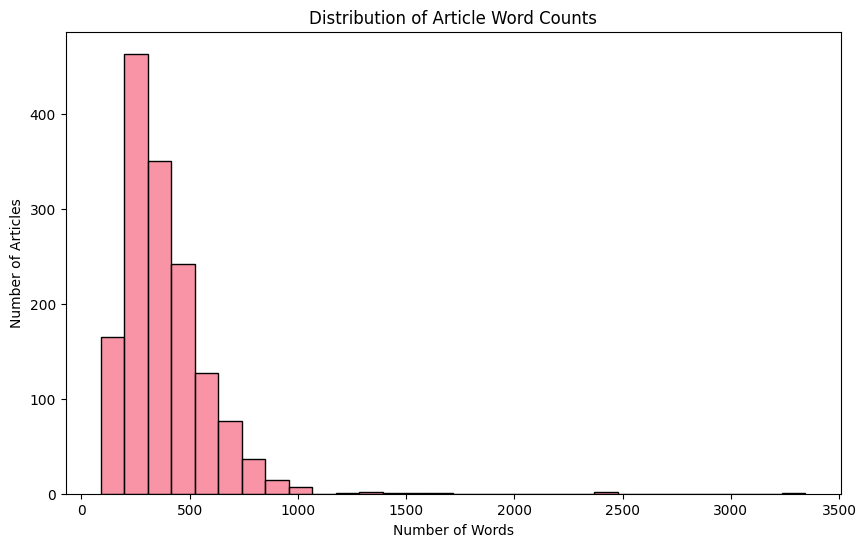


📰 SOURCE DISTRIBUTION
source
BBC News    1490
Name: count, dtype: int64

✅ DATA QUALITY CHECK
Duplicate articles: 50
Empty articles: 0
Shortest article: 90 words
Longest article: 3345 words


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check for missing values
print("\n🔍 MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())

# Analyze article length
df['text_length'] = df['content'].str.len()
df['word_count'] = df['content'].str.split().str.len()

print("\n📝 ARTICLE LENGTH STATISTICS")
print("=" * 50)
print(df['word_count'].describe())

# Visualize word counts
plt.figure(figsize=(10,6))
sns.histplot(df['word_count'], bins=30)
plt.title('Distribution of Article Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Number of Articles')
plt.show()

# Source distribution
print("\n📰 SOURCE DISTRIBUTION")
print("=" * 50)
print(df['source'].value_counts())

# Data quality checks
print("\n✅ DATA QUALITY CHECK")
print("=" * 50)
print(f"Duplicate articles: {df.duplicated(subset=['content']).sum()}")
print(f"Empty articles: {(df['content'].str.len() == 0).sum()}")
print(f"Shortest article: {df['word_count'].min()} words")
print(f"Longest article: {df['word_count'].max()} words")

## 🧹 Text Preprocessing Pipeline

### 🎯 Module 2: Advanced Text Preprocessing

Now we'll implement a comprehensive text preprocessing pipeline that cleans and normalizes our news articles. This is crucial for all downstream NLP tasks.

**Key Preprocessing Steps:**
1. **Text Cleaning:** Remove HTML, URLs, special characters
2. **Tokenization:** Split text into individual words
3. **Normalization:** Convert to lowercase, handle contractions
4. **Stop Word Removal:** Remove common words that don't carry meaning
5. **Lemmatization:** Reduce words to their base form

**💡 Think About:** Why is preprocessing so important? What happens if we skip these steps?

In [7]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import re
import pandas as pd
from collections import Counter

# Initialize preprocessing tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Comprehensive text cleaning function.
    Removes HTML, URLs, emails, special characters, numbers, and extra spaces.
    """
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    """
    Complete preprocessing pipeline:
    cleaning, tokenization, stop word removal, lemmatization.
    """
    text = clean_text(text)

    if not text:
        return ""

    # Simple tokenization after cleaning
    tokens = text.split()

    # Remove stop words
    if remove_stopwords:
        tokens = [token for token in tokens if token not in stop_words]

    # Lemmatize
    if lemmatize:
        tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Remove very short words
    tokens = [token for token in tokens if len(token) > 2]

    return ' '.join(tokens)

# Test the preprocessing function
sample_text = "Apple Inc. announced record quarterly earnings today! Visit https://apple.com for more info. #TechNews"

print("Original text:")
print(sample_text)

print("\nCleaned text:")
print(clean_text(sample_text))

print("\nFully preprocessed text:")
print(preprocess_text(sample_text))

Original text:
Apple Inc. announced record quarterly earnings today! Visit https://apple.com for more info. #TechNews

Cleaned text:
apple inc announced record quarterly earnings today visit for more info technews

Fully preprocessed text:


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


apple inc announced record quarterly earnings today visit info technews


In [8]:
# Apply preprocessing to the dataset
print("🧹 Preprocessing all articles...")

# Make sure required columns exist
if 'title' not in df.columns:
    df['title'] = df['content'].str.split().str[:8].str.join(' ')

if 'content' not in df.columns:
    raise ValueError("The dataframe must contain a 'content' column.")

# Fill missing text values just in case
df['title'] = df['title'].fillna("")
df['content'] = df['content'].fillna("")

# Create new columns for processed text
df['title_clean'] = df['title'].apply(clean_text)
df['content_clean'] = df['content'].apply(clean_text)
df['title_processed'] = df['title'].apply(preprocess_text)
df['content_processed'] = df['content'].apply(preprocess_text)

# Combine title and content for full article analysis
df['full_text'] = df['title'].astype(str) + ' ' + df['content'].astype(str)
df['full_text_processed'] = df['full_text'].apply(preprocess_text)

print("✅ Preprocessing complete!")

# Show before and after examples
print("\n📝 BEFORE AND AFTER EXAMPLES")
print("=" * 60)
for i in range(min(3, len(df))):
    print(f"\nExample {i+1}:")
    print(f"Original: {df.iloc[i]['full_text'][:150]}...")
    print(f"Processed: {df.iloc[i]['full_text_processed'][:150]}...")

# Analyze preprocessing results
print("\n📊 PREPROCESSING ANALYSIS")
print("=" * 60)

df['original_word_count'] = df['full_text'].str.split().str.len()
df['processed_word_count'] = df['full_text_processed'].str.split().str.len()

print(f"Average original word count: {df['original_word_count'].mean():.2f}")
print(f"Average processed word count: {df['processed_word_count'].mean():.2f}")

original_words = ' '.join(df['full_text'].astype(str).str.lower()).split()
processed_words = ' '.join(df['full_text_processed'].astype(str)).split()

print(f"Unique words before preprocessing: {len(set(original_words))}")
print(f"Unique words after preprocessing: {len(set(processed_words))}")

common_words = Counter(processed_words).most_common(20)

print("\nMost common words after preprocessing:")
for word, count in common_words:
    print(f"{word}: {count}")

🧹 Preprocessing all articles...
✅ Preprocessing complete!

📝 BEFORE AND AFTER EXAMPLES

Example 1:
Original: worldcom...ex-boss...launches...defence...lawyers...defending...former...worldcom worldcom ex-boss launches defence lawyers defending former worldcom ...
Processed: worldcomexbosslaunchesdefencelawyersdefendingformerworldcom worldcom exboss launch defence lawyer defending former worldcom chief bernie ebbers batter...

Example 2:
Original: german...business...confidence...slides...german...business...confidence...fell german business confidence slides german business confidence fell in f...
Processed: germanbusinessconfidenceslidesgermanbusinessconfidencefell german business confidence slide german business confidence fell february knocking hope spe...

Example 3:
Original: bbc...poll...indicates...economic...gloom...citizens...in...a bbc poll indicates economic gloom citizens in a majority of nations surveyed in a bbc wo...
Processed: bbcpollindicateseconomicgloomcitizensina bbc

## 📊 Feature Extraction and Statistical Analysis

### 🎯 Module 3: TF-IDF Analysis

Now we'll extract numerical features from our text using TF-IDF (Term Frequency-Inverse Document Frequency). This technique helps us identify the most important words in each document and across the entire corpus.

**TF-IDF Key Concepts:**
- **Term Frequency (TF):** How often a word appears in a document
- **Inverse Document Frequency (IDF):** How rare a word is across all documents
- **TF-IDF Score:** TF × IDF - balances frequency with uniqueness

**💡 Business Value:** TF-IDF helps us identify the most distinctive and important terms for each news category.

In [9]:
# Create TF-IDF vectorizer
# 💡 TIP: Experiment with different parameters:
# - max_features: limit vocabulary size
# - ngram_range: include phrases (1,1) for words, (1,2) for words+bigrams
# - min_df: ignore terms that appear in less than min_df documents
# - max_df: ignore terms that appear in more than max_df fraction of documents
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,  # Limit vocabulary for computational efficiency
    ngram_range=(1, 2),  # Include unigrams and bigrams
    min_df=2,  # Ignore terms that appear in less than 2 documents
    max_df=0.8  # Ignore terms that appear in more than 80% of documents
)

# Fit and transform the processed text
print("🔢 Creating TF-IDF features...")
tfidf_matrix = tfidf_vectorizer.fit_transform(df['full_text_processed'])
feature_names = tfidf_vectorizer.get_feature_names_out()

print(f"✅ TF-IDF matrix created!")
print(f"📊 Shape: {tfidf_matrix.shape}")
print(f"📝 Vocabulary size: {len(feature_names)}")
print(f"🔢 Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")

# Convert to DataFrame for easier analysis
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
tfidf_df['category'] = df['category'].values

print("\n🔍 Sample TF-IDF features:")
print(tfidf_df.iloc[:3, :10])  # Show first 3 rows and 10 features

🔢 Creating TF-IDF features...
✅ TF-IDF matrix created!
📊 Shape: (1490, 5000)
📝 Vocabulary size: 5000
🔢 Sparsity: 97.50%

🔍 Sample TF-IDF features:
   abc  ability  able  abroad  absence  absolute  absolutely  abuse  abused  \
0  0.0      0.0   0.0     0.0      0.0       0.0         0.0    0.0     0.0   
1  0.0      0.0   0.0     0.0      0.0       0.0         0.0    0.0     0.0   
2  0.0      0.0   0.0     0.0      0.0       0.0         0.0    0.0     0.0   

   academy  
0      0.0  
1      0.0  
2      0.0  


🏷️ TOP TF-IDF TERMS BY CATEGORY

📰 BUSINESS:
  firm: 0.0390
  company: 0.0372
  market: 0.0344
  bank: 0.0336
  year: 0.0335
  growth: 0.0332
  economy: 0.0317
  sale: 0.0316
  share: 0.0307
  profit: 0.0273

📰 TECH:
  mobile: 0.0514
  phone: 0.0469
  people: 0.0458
  technology: 0.0410
  game: 0.0381
  user: 0.0378
  service: 0.0370
  software: 0.0365
  computer: 0.0330
  net: 0.0308

📰 POLITICS:
  labour: 0.0649
  election: 0.0605
  blair: 0.0559
  party: 0.0538
  tory: 0.0462
  would: 0.0456
  government: 0.0455
  minister: 0.0428
  brown: 0.0384
  tax: 0.0329

📰 SPORT:
  game: 0.0448
  england: 0.0374
  win: 0.0341
  player: 0.0322
  match: 0.0305
  champion: 0.0293
  cup: 0.0278
  team: 0.0259
  chelsea: 0.0255
  injury: 0.0249

📰 ENTERTAINMENT:
  film: 0.0995
  award: 0.0524
  best: 0.0460
  show: 0.0376
  star: 0.0372
  music: 0.0356
  band: 0.0349
  actor: 0.0335
  year: 0.0300
  album: 0.0290


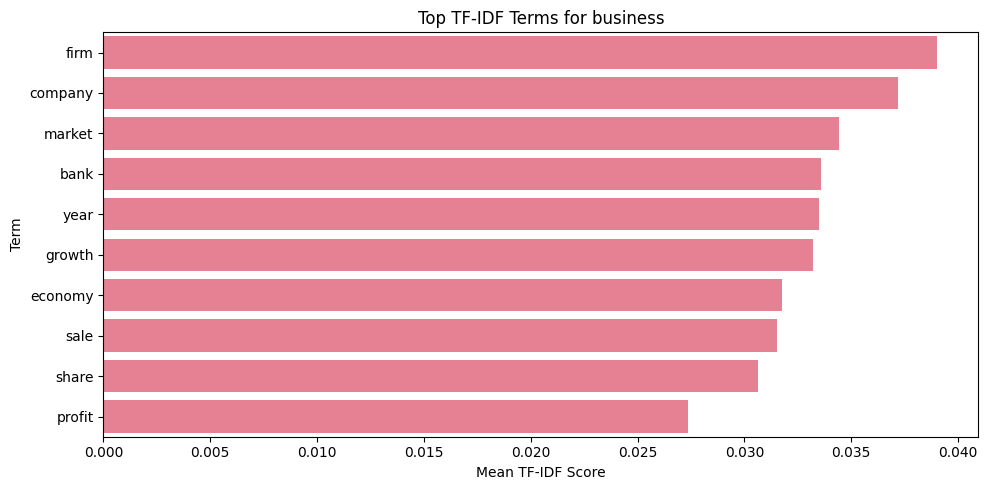

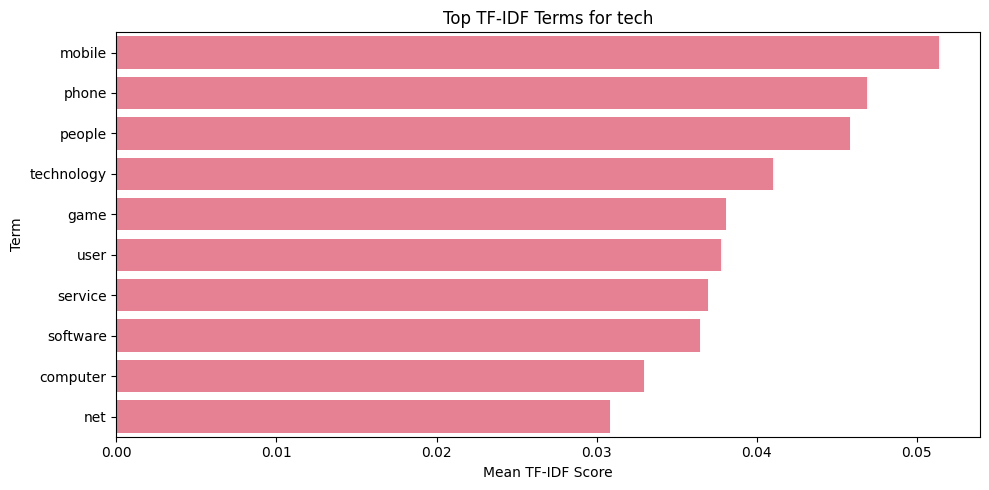

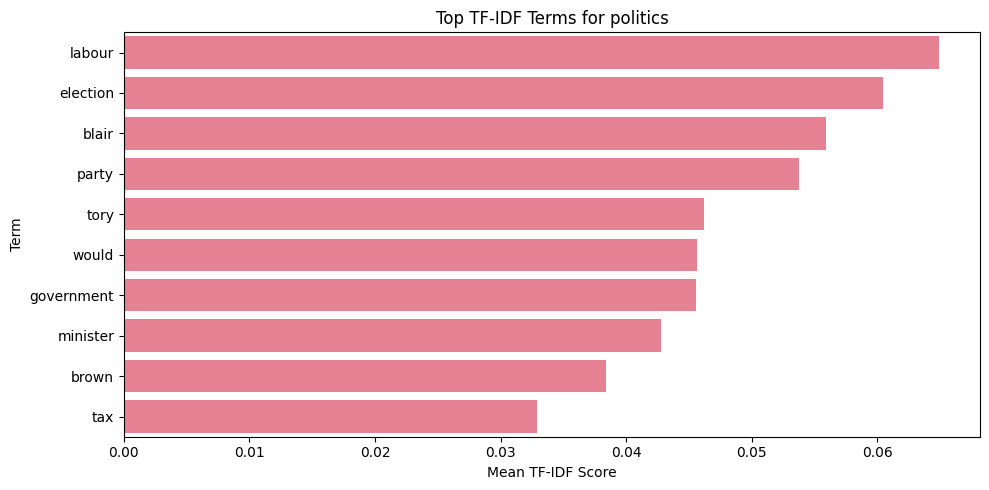

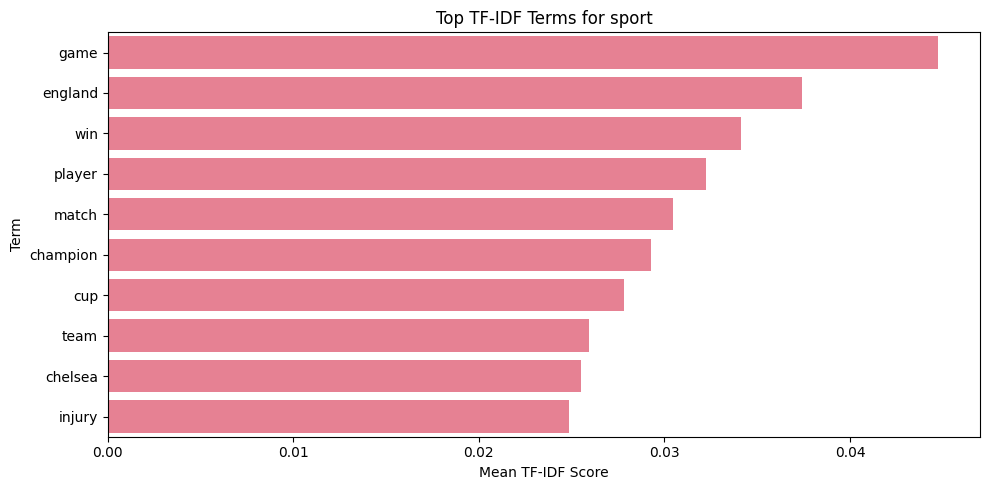

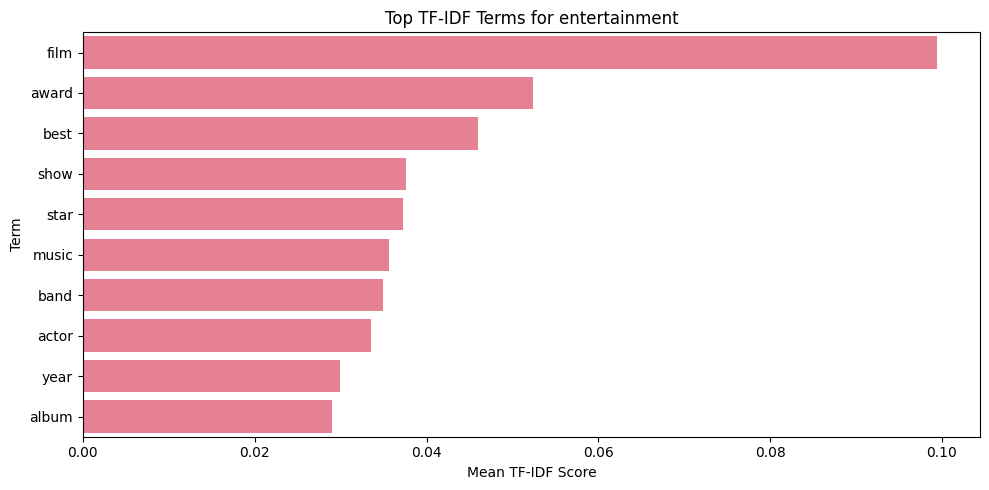

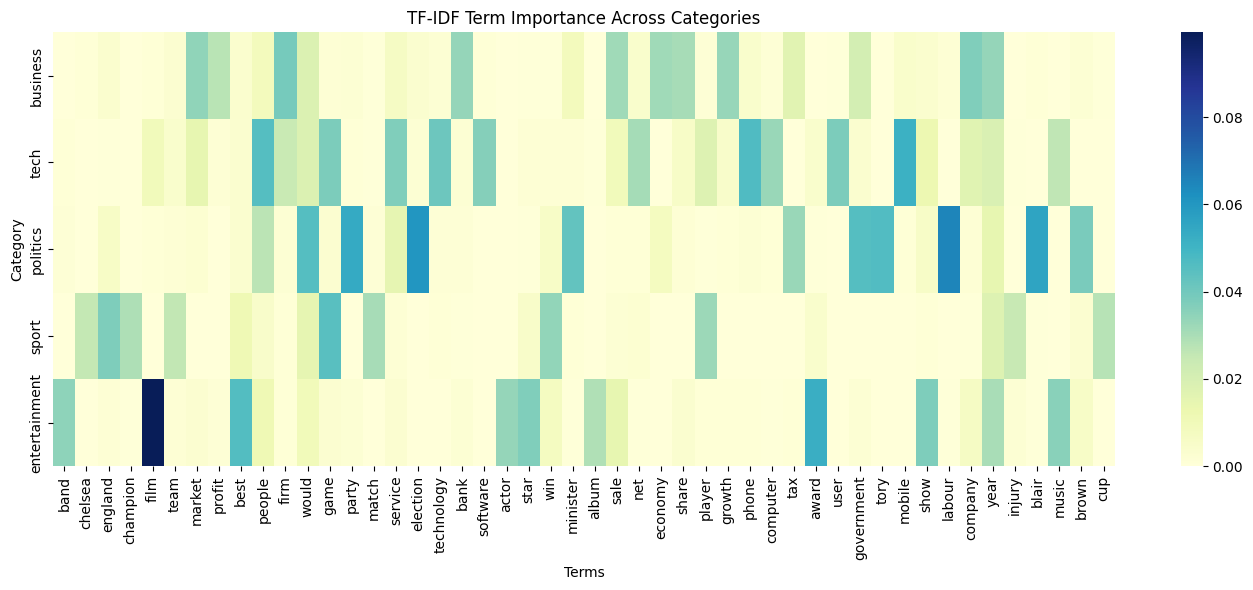

In [10]:
# Analyze most important terms per category
def get_top_tfidf_terms(category, n_terms=10):
    """
    Get top TF-IDF terms for a specific category.
    """
    category_data = tfidf_df[tfidf_df['category'] == category]
    mean_scores = category_data.drop('category', axis=1).mean().sort_values(ascending=False)
    return mean_scores.head(n_terms)

# Analyze top terms for each category
print("🏷️ TOP TF-IDF TERMS BY CATEGORY")
print("=" * 50)

categories = df['category'].unique()
category_terms = {}

for category in categories:
    top_terms = get_top_tfidf_terms(category, n_terms=10)
    category_terms[category] = top_terms

    print(f"\n📰 {category.upper()}:")
    for term, score in top_terms.items():
        print(f"  {term}: {score:.4f}")

# Bar charts of top terms by category
for category, terms in category_terms.items():
    plt.figure(figsize=(10, 5))
    sns.barplot(x=terms.values, y=terms.index)
    plt.title(f"Top TF-IDF Terms for {category}")
    plt.xlabel("Mean TF-IDF Score")
    plt.ylabel("Term")
    plt.tight_layout()
    plt.show()

# Heatmap of top term importance across categories
top_all_terms = list(set([term for terms in category_terms.values() for term in terms.index]))

heatmap_data = []

for category in categories:
    category_data = tfidf_df[tfidf_df['category'] == category]
    mean_scores = category_data.drop('category', axis=1).mean()
    heatmap_data.append([mean_scores.get(term, 0) for term in top_all_terms])

heatmap_df = pd.DataFrame(heatmap_data, index=categories, columns=top_all_terms)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_df, cmap="YlGnBu", annot=False)
plt.title("TF-IDF Term Importance Across Categories")
plt.xlabel("Terms")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## 🏷️ Part-of-Speech Analysis

### 🎯 Module 4: Grammatical Pattern Analysis

Let's analyze the grammatical patterns in different news categories using Part-of-Speech (POS) tagging. This can reveal interesting differences in writing styles between categories.

**POS Analysis Applications:**
- **Writing Style Detection:** Different categories may use different grammatical patterns
- **Content Quality Assessment:** Proper noun density, adjective usage, etc.
- **Feature Engineering:** POS tags can be features for classification

**💡 Hypothesis:** Sports articles might have more action verbs, while business articles might have more numbers and proper nouns.

In [11]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

from nltk import pos_tag
from collections import Counter

def analyze_pos_patterns(text):
    """
    Analyze POS patterns in text.
    Uses simple split tokenization to avoid NLTK punkt issues.
    """
    if not text or pd.isna(text):
        return {}

    # Clean and tokenize text
    cleaned = clean_text(text)
    tokens = cleaned.split()

    if len(tokens) == 0:
        return {}

    # POS tagging
    pos_tags = pos_tag(tokens)

    # Count POS categories
    pos_counts = Counter([tag for word, tag in pos_tags])
    total_words = len(pos_tags)

    # Convert counts to proportions
    pos_proportions = {pos: count / total_words for pos, count in pos_counts.items()}

    return pos_proportions

# Apply POS analysis to all articles
print("🏷️ Analyzing POS patterns...")

pos_results = []

for idx, row in df.iterrows():
    pos_analysis = analyze_pos_patterns(row['full_text'])
    pos_analysis['category'] = row['category']
    pos_analysis['article_id'] = row['article_id']
    pos_results.append(pos_analysis)

# Convert to DataFrame
pos_df = pd.DataFrame(pos_results).fillna(0)

print("✅ POS analysis complete!")
print(f"📊 Found {len(pos_df.columns) - 2} different POS tags")

# Show sample results
print("\n📝 Sample POS analysis:")
display(pos_df.head())

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


🏷️ Analyzing POS patterns...
✅ POS analysis complete!
📊 Found 37 different POS tags

📝 Sample POS analysis:


,NN,VBZ,NNS,VBG,JJ,IN,DT,VBP,VBN,PRP$,...,RBS,FW,WP$,NNP,NNPS,'',POS,UH,$,SYM
0,0.257627,0.023729,0.122034,0.030508,0.091525,0.118644,0.071186,0.023729,0.044068,0.013559,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.243671,0.015823,0.075949,0.034810,0.126582,0.145570,0.088608,0.015823,0.031646,0.006329,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.202454,0.030675,0.089980,0.030675,0.083845,0.137014,0.106339,0.020450,0.034765,0.018405,...,0.006135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.150641,0.022436,0.115385,0.025641,0.089744,0.131410,0.067308,0.049679,0.022436,0.014423,...,0.001603,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.248571,0.025714,0.088571,0.040000,0.097143,0.134286,0.111429,0.017143,0.028571,0.017143,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


📊 POS PATTERNS BY CATEGORY

🎯 Key POS patterns by category:
                   NN     NNS     NNP    NNPS      VB     VBD     VBG     VBN  \
category                                                                        
business       0.2422  0.0806  0.0007  0.0000  0.0370  0.0455  0.0227  0.0314   
entertainment  0.2650  0.0620  0.0007  0.0000  0.0304  0.0502  0.0221  0.0325   
politics       0.2214  0.0727  0.0003  0.0002  0.0477  0.0493  0.0229  0.0326   
sport          0.2403  0.0518  0.0006  0.0000  0.0413  0.0493  0.0196  0.0270   
tech           0.2062  0.0915  0.0006  0.0000  0.0452  0.0325  0.0266  0.0297   

                  VBP     VBZ      JJ     JJR     JJS      RB     RBR     RBS  \
category                                                                        
business       0.0206  0.0273  0.0972  0.0049  0.0039  0.0306  0.0021  0.0007   
entertainment  0.0222  0.0252  0.0972  0.0027  0.0053  0.0307  0.0012  0.0011   
politics       0.0238  0.0246  0.0926  0.0033  0

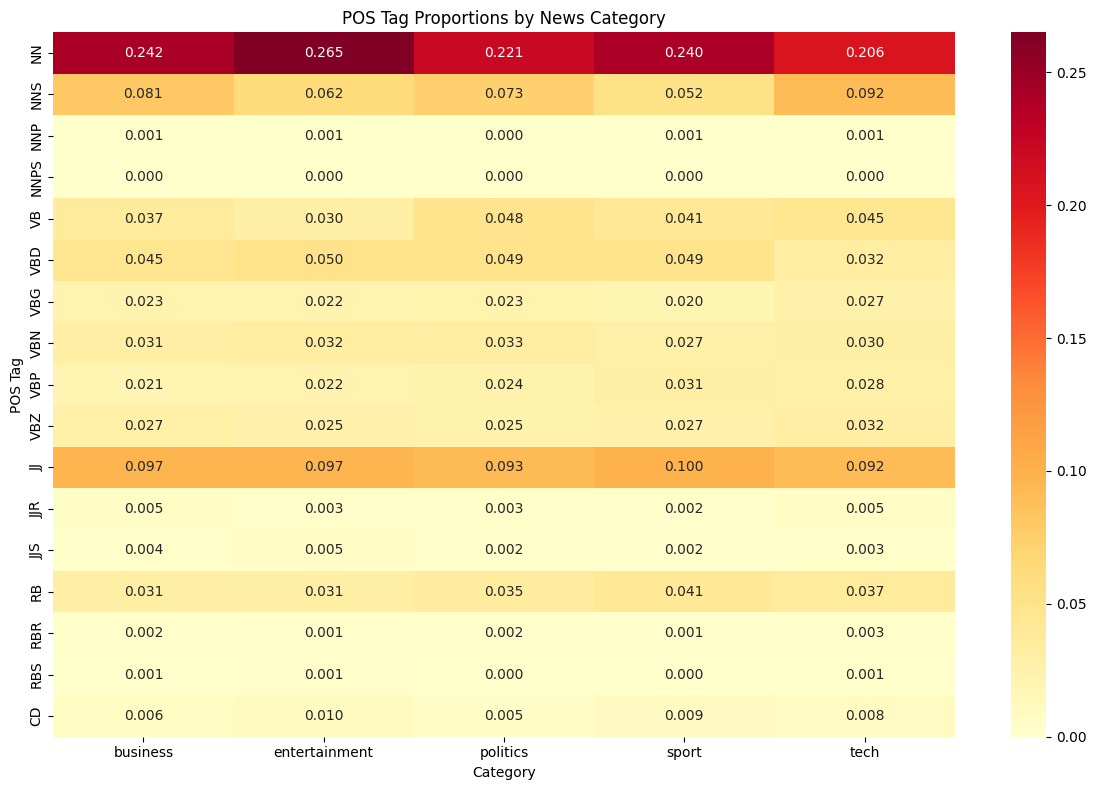


💡 ANALYSIS QUESTIONS:
1. Which category has the highest proportion of proper nouns (NNP/NNPS)?
2. Which category uses the most action verbs (VB, VBD, VBG)?
3. Are there interesting patterns in adjective (JJ) usage?
4. How does number (CD) usage vary across categories?


In [12]:
# Analyze POS patterns by category
print("📊 POS PATTERNS BY CATEGORY")
print("=" * 50)

# Group by category and calculate mean proportions
pos_by_category = pos_df.groupby('category').mean()

# Focus on major POS categories
major_pos = ['NN', 'NNS', 'NNP', 'NNPS', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ',
             'JJ', 'JJR', 'JJS', 'RB', 'RBR', 'RBS', 'CD']

# Filter to only include major POS tags that exist in our data
available_pos = [pos for pos in major_pos if pos in pos_by_category.columns]

if available_pos:
    pos_summary = pos_by_category[available_pos]

    print("\n🎯 Key POS patterns by category:")
    print(pos_summary.round(4))

    # Create visualization
    plt.figure(figsize=(12, 8))
    sns.heatmap(pos_summary.T, annot=True, cmap='YlOrRd', fmt='.3f')
    plt.title('POS Tag Proportions by News Category')
    plt.xlabel('Category')
    plt.ylabel('POS Tag')
    plt.tight_layout()
    plt.show()

    # 💡 STUDENT TASK: Analyze the patterns
    # - Which categories use more nouns vs verbs?
    # - Do business articles have more numbers (CD)?
    # - Are there differences in adjective usage?

    print("\n💡 ANALYSIS QUESTIONS:")
    print("1. Which category has the highest proportion of proper nouns (NNP/NNPS)?")
    print("2. Which category uses the most action verbs (VB, VBD, VBG)?")
    print("3. Are there interesting patterns in adjective (JJ) usage?")
    print("4. How does number (CD) usage vary across categories?")
else:
    print("⚠️ No major POS tags found in the analysis. Check your POS tagging implementation.")

In [13]:
# Additional POS interpretation for student task

print("\n🧠 POS PATTERN INTERPRETATION")
print("=" * 50)

# Proper nouns
proper_noun_cols = [col for col in ['NNP', 'NNPS'] if col in pos_by_category.columns]
if proper_noun_cols:
    proper_nouns = pos_by_category[proper_noun_cols].sum(axis=1)
    print(f"Highest proper noun usage: {proper_nouns.idxmax()} ({proper_nouns.max():.4f})")

# Action verbs
verb_cols = [col for col in ['VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ'] if col in pos_by_category.columns]
if verb_cols:
    verbs = pos_by_category[verb_cols].sum(axis=1)
    print(f"Highest verb usage: {verbs.idxmax()} ({verbs.max():.4f})")

# Adjectives
adj_cols = [col for col in ['JJ', 'JJR', 'JJS'] if col in pos_by_category.columns]
if adj_cols:
    adjectives = pos_by_category[adj_cols].sum(axis=1)
    print(f"Highest adjective usage: {adjectives.idxmax()} ({adjectives.max():.4f})")

# Numbers
if 'CD' in pos_by_category.columns:
    numbers = pos_by_category['CD']
    print(f"Highest number usage: {numbers.idxmax()} ({numbers.max():.4f})")


🧠 POS PATTERN INTERPRETATION
Highest proper noun usage: business (0.0008)
Highest verb usage: politics (0.2010)
Highest adjective usage: business (0.1059)
Highest number usage: entertainment (0.0102)


## 🌳 Syntax Parsing and Semantic Analysis

### 🎯 Module 5: Understanding Sentence Structure

Now we'll use spaCy to perform dependency parsing and extract semantic relationships from our news articles. This helps us understand not just what words are present, but how they relate to each other.

**Dependency Parsing Applications:**
- **Relationship Extraction:** Find connections between entities
- **Event Detection:** Identify who did what to whom
- **Information Extraction:** Extract structured facts from unstructured text

**💡 Business Value:** Understanding sentence structure helps extract more precise information about events, relationships, and actions mentioned in news articles.

In [14]:
def extract_syntactic_features(text):
    """
    Extract syntactic features using spaCy dependency parsing

    💡 TIP: This function should extract:
    - Dependency relations
    - Subject-verb-object patterns
    - Noun phrases
    - Verb phrases
    """
    if not text or pd.isna(text):
        return {}

    # Process text with spaCy
    doc = nlp(str(text))

    features = {
        'num_sentences': len(list(doc.sents)),
        'num_tokens': len(doc),
        'dependency_relations': [],
        'noun_phrases': [],
        'verb_phrases': [],
        'subjects': [],
        'objects': []
    }

    # 🚀 YOUR CODE HERE: Extract syntactic features

    # Extract dependency relations
    for token in doc:
        if not token.is_space and not token.is_punct:
            features['dependency_relations'].append(token.dep_)

    # Extract noun phrases
    for chunk in doc.noun_chunks:
        features['noun_phrases'].append(chunk.text.lower())

    # Extract subjects and objects
    for token in doc:
        if token.dep_ in ['nsubj', 'nsubjpass']:  # Subjects
            features['subjects'].append(token.text.lower())
        elif token.dep_ in ['dobj', 'iobj', 'pobj']:  # Objects
            features['objects'].append(token.text.lower())

    # Count dependency types
    dep_counts = Counter(features['dependency_relations'])
    features['dependency_counts'] = dict(dep_counts)

    return features

# Apply syntactic analysis to sample articles
print("🌳 Performing syntactic analysis...")

# Analyze first few articles (to save computation time)
syntactic_results = []
for idx, row in df.head(5).iterrows():  # Limit to first 5 for demo
    features = extract_syntactic_features(row['full_text'])
    features['category'] = row['category']
    features['article_id'] = row['article_id']
    syntactic_results.append(features)

print("✅ Syntactic analysis complete!")

# Display results
for i, result in enumerate(syntactic_results):
    print(f"\n📰 Article {i+1} ({result['category']}):")
    print(f"  Sentences: {result['num_sentences']}")
    print(f"  Tokens: {result['num_tokens']}")
    print(f"  Noun phrases: {result['noun_phrases'][:3]}...")  # Show first 3
    print(f"  Subjects: {result['subjects'][:3]}...")  # Show first 3
    print(f"  Objects: {result['objects'][:3]}...")  # Show first 3

🌳 Performing syntactic analysis...
✅ Syntactic analysis complete!

📰 Article 1 (business):
  Sentences: 15
  Tokens: 363
  Noun phrases: ['worldcom', 'ex-boss...launches', 'defence']...
  Subjects: ['worldcom', '-', 'boss']...
  Objects: ['ebbers', 'battery', 'charges']...

📰 Article 2 (business):
  Sentences: 15
  Tokens: 383
  Noun phrases: ['german', 'business', 'confidence']...
  Subjects: ['german', 'confidence', 'ifo']...
  Objects: ['confidence', 'february', 'hopes']...

📰 Article 3 (business):
  Sentences: 24
  Tokens: 602
  Noun phrases: ['bbc...poll', 'economic...gloom', 'citizens']...
  Subjects: ['poll', 'gloom', 'poll']...
  Objects: ['citizens', 'majority', 'nations']...

📰 Article 4 (tech):
  Sentences: 31
  Tokens: 739
  Noun phrases: ['lifestyle...governs', 'mobile...choice', '...funkier lifestyle  governs']...
  Subjects: ['governs', 'firms', 'firms']...
  Objects: ['choice', 'hardware', 'research']...

📰 Article 5 (business):
  Sentences: 17
  Tokens: 432
  Noun phra

In [15]:
# Visualize dependency parsing for a sample sentence
from spacy import displacy

# Choose a sample sentence
sample_sentence = df.iloc[0]['content']  # First article's content
print(f"📝 Sample sentence: {sample_sentence}")

# Process with spaCy
doc = nlp(sample_sentence)

# Display dependency tree (this works best in Jupyter)
print("\n🌳 Dependency Parse Visualization:")
try:
    # This will create an interactive visualization in Jupyter
    displacy.render(doc, style="dep", jupyter=True)
except:
    # Fallback: print dependency information
    print("\n🔗 Dependency Relations:")
    for token in doc:
        if not token.is_space and not token.is_punct:
            print(f"  {token.text} --> {token.dep_} --> {token.head.text}")

# 💡 STUDENT TASK: Extend syntactic analysis
# - Compare syntactic complexity across categories
# - Extract action patterns (who did what)
# - Identify most common dependency relations per category
# - Create features for classification based on syntax

📝 Sample sentence: worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper  worldcom s ex-head of internal accounting  alerted directors to irregular accounting practices at the us telecoms giant in 2002. her warnings led to the collapse of the firm following the discovery of an $11bn (£5.7bn) accounting fraud. mr ebbers has pleaded not guilty to charges of fraud and conspiracy.  prosecution lawyers have argued that mr ebbers orchestrated a series of accounting tricks at worldcom  ordering employees to hide expenses and inflate revenues to meet wall street earnings estimates. but ms cooper  who now runs her own consulting business  told a jury in new york on wednesday that external auditors arthur andersen had approved worldcom s accounting in early 2001 and 2002. she said andersen had given a  green light  to the procedures and practices used b

## 😊 Sentiment and Emotion Analysis

### 🎯 Module 6: Understanding Emotional Tone

Let's analyze the sentiment and emotional tone of our news articles. This can reveal interesting patterns about how different types of news are presented and perceived.

**Sentiment Analysis Applications:**
- **Media Bias Detection:** Identify emotional slant in news coverage
- **Public Opinion Tracking:** Monitor sentiment trends over time
- **Content Recommendation:** Suggest articles based on emotional tone

**💡 Hypothesis:** Different news categories might have different emotional profiles - sports might be more positive, politics more negative, etc.

In [16]:
# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    """
    Analyze sentiment using VADER sentiment analyzer

    💡 TIP: VADER returns:
    - compound: overall sentiment (-1 to 1)
    - pos: positive score (0 to 1)
    - neu: neutral score (0 to 1)
    - neg: negative score (0 to 1)
    """
    if not text or pd.isna(text):
        return {'compound': 0, 'pos': 0, 'neu': 1, 'neg': 0}

    # 🚀 YOUR CODE HERE: Implement sentiment analysis
    scores = sia.polarity_scores(str(text))

    # Add interpretation
    if scores['compound'] >= 0.05:
        scores['sentiment_label'] = 'positive'
    elif scores['compound'] <= -0.05:
        scores['sentiment_label'] = 'negative'
    else:
        scores['sentiment_label'] = 'neutral'

    return scores

# Apply sentiment analysis to all articles
print("😊 Analyzing sentiment...")

sentiment_results = []
for idx, row in df.iterrows():
    # Analyze both title and content
    title_sentiment = analyze_sentiment(row['title'])
    content_sentiment = analyze_sentiment(row['content'])
    full_sentiment = analyze_sentiment(row['full_text'])

    result = {
        'article_id': row['article_id'],
        'category': row['category'],
        'title_sentiment': title_sentiment['compound'],
        'title_label': title_sentiment['sentiment_label'],
        'content_sentiment': content_sentiment['compound'],
        'content_label': content_sentiment['sentiment_label'],
        'full_sentiment': full_sentiment['compound'],
        'full_label': full_sentiment['sentiment_label'],
        'pos_score': full_sentiment['pos'],
        'neu_score': full_sentiment['neu'],
        'neg_score': full_sentiment['neg']
    }
    sentiment_results.append(result)

# Convert to DataFrame
sentiment_df = pd.DataFrame(sentiment_results)

print("✅ Sentiment analysis complete!")
print(f"📊 Analyzed {len(sentiment_df)} articles")

# Display sample results
print("\n📝 Sample sentiment results:")
print(sentiment_df[['category', 'full_sentiment', 'full_label']].head())

😊 Analyzing sentiment...
✅ Sentiment analysis complete!
📊 Analyzed 1490 articles

📝 Sample sentiment results:
   category  full_sentiment full_label
0  business         -0.9701   negative
1  business          0.7623   positive
2  business         -0.9318   negative
3      tech          0.9554   positive
4  business         -0.9486   negative


📊 SENTIMENT ANALYSIS BY CATEGORY

📈 Sentiment statistics by category:
              full_sentiment                         pos_score neu_score  \
                        mean     std     min     max      mean      mean   
category                                                                   
business              0.2404  0.8370 -0.9985  0.9995    0.0923    0.8375   
entertainment         0.5991  0.6796 -0.9978  0.9999    0.1352    0.8112   
politics              0.0578  0.8811 -0.9984  0.9999    0.0945    0.8188   
sport                 0.5541  0.7244 -0.9967  0.9996    0.1356    0.7940   
tech                  0.5233  0.7557 -0.9991  0.9993    0.0893    0.8601   

              neg_score  
                   mean  
category                 
business         0.0702  
entertainment    0.0536  
politics         0.0867  
sport            0.0704  
tech             0.0506  

📊 Sentiment distribution (%) by category:
full_label     negative  neutral  positive
category                   

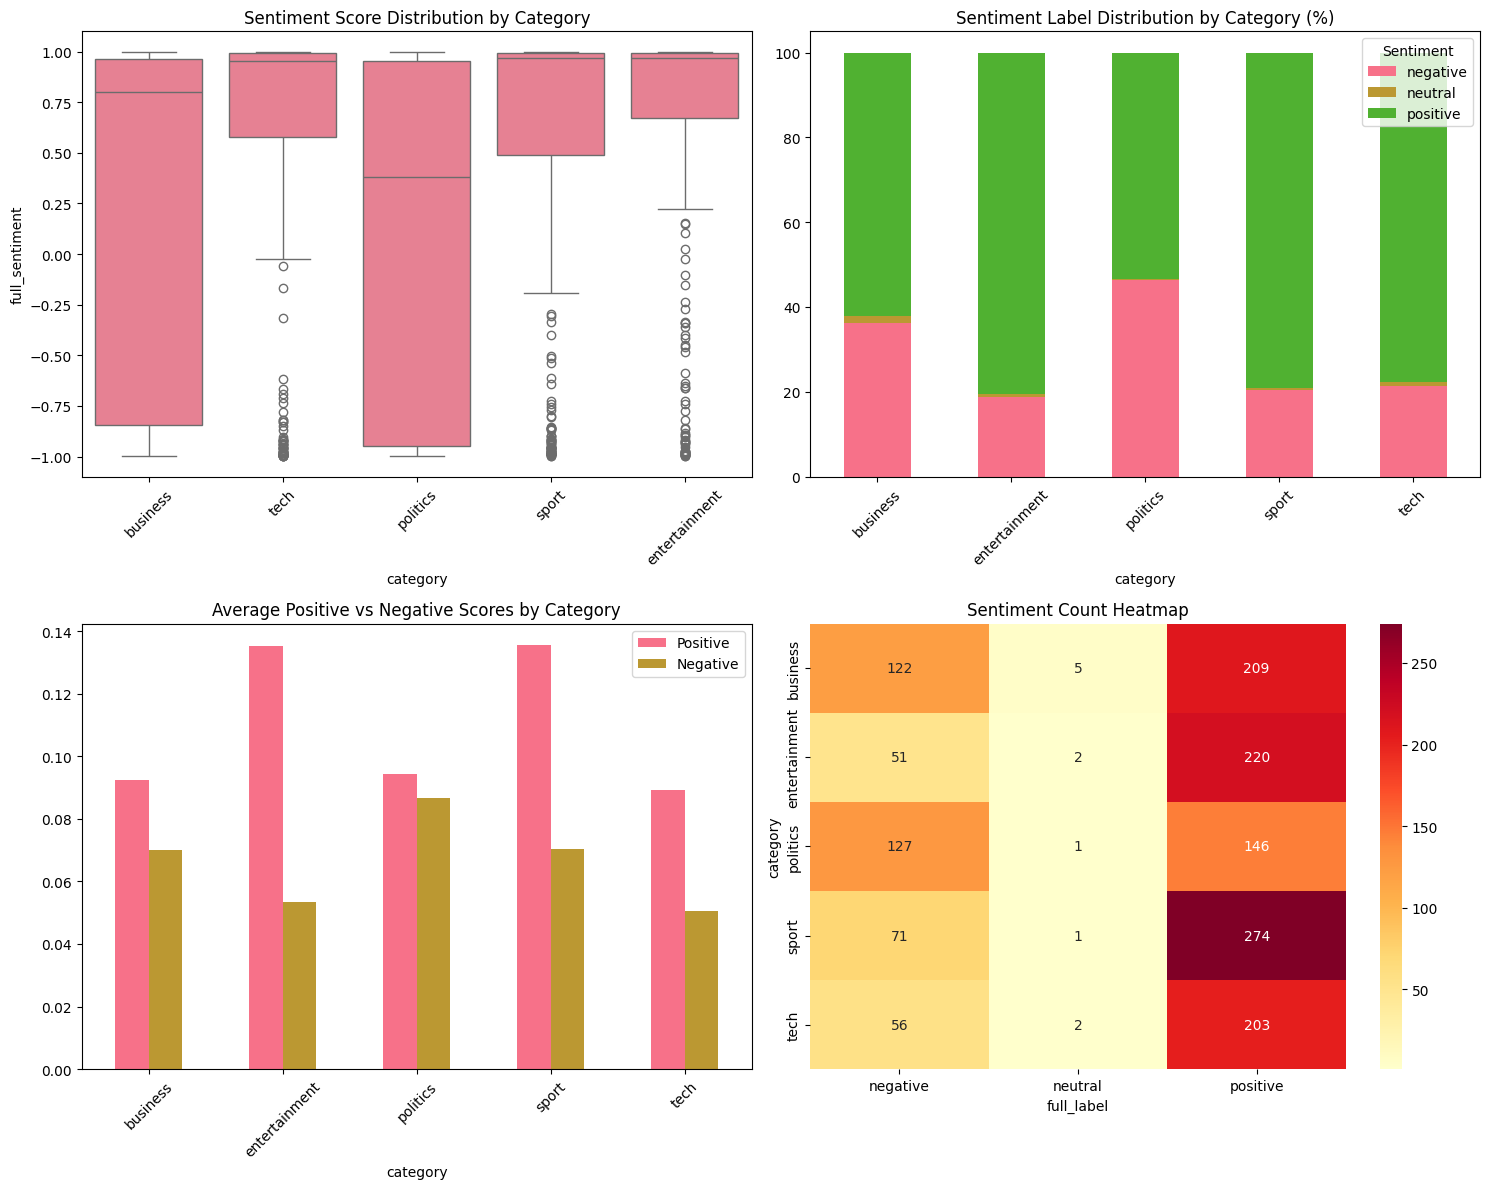

In [17]:
# Analyze sentiment patterns by category
print("📊 SENTIMENT ANALYSIS BY CATEGORY")
print("=" * 50)

# Calculate sentiment statistics by category
sentiment_by_category = sentiment_df.groupby('category').agg({
    'full_sentiment': ['mean', 'std', 'min', 'max'],
    'pos_score': 'mean',
    'neu_score': 'mean',
    'neg_score': 'mean'
}).round(4)

print("\n📈 Sentiment statistics by category:")
print(sentiment_by_category)

# Sentiment distribution by category
sentiment_dist = sentiment_df.groupby(['category', 'full_label']).size().unstack(fill_value=0)
sentiment_dist_pct = sentiment_dist.div(sentiment_dist.sum(axis=1), axis=0) * 100

print("\n📊 Sentiment distribution (%) by category:")
print(sentiment_dist_pct.round(2))

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Sentiment scores by category
sns.boxplot(data=sentiment_df, x='category', y='full_sentiment', ax=axes[0,0])
axes[0,0].set_title('Sentiment Score Distribution by Category')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Sentiment label distribution
sentiment_dist_pct.plot(kind='bar', ax=axes[0,1], stacked=True)
axes[0,1].set_title('Sentiment Label Distribution by Category (%)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend(title='Sentiment')

# 3. Positive vs Negative scores
category_means = sentiment_df.groupby('category')[['pos_score', 'neg_score']].mean()
category_means.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Average Positive vs Negative Scores by Category')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(['Positive', 'Negative'])

# 4. Sentiment vs Category heatmap
sentiment_pivot = sentiment_df.pivot_table(values='full_sentiment', index='category',
                                         columns='full_label', aggfunc='count', fill_value=0)
sns.heatmap(sentiment_pivot, annot=True, fmt='d', ax=axes[1,1], cmap='YlOrRd')
axes[1,1].set_title('Sentiment Count Heatmap')

plt.tight_layout()
plt.show()

# 💡 STUDENT TASK: Analyze sentiment patterns
# - Which categories are most positive/negative?
# - Are there differences between title and content sentiment?
# - How does sentiment vary within categories?
# - Can sentiment be used as a feature for classification?

## 🏷️ Text Classification System

### 🎯 Module 7: Building the News Classifier

Now we'll build the core of our NewsBot system - a multi-class text classifier that can automatically categorize news articles. We'll compare different algorithms and evaluate their performance.

**Classification Pipeline:**
1. **Feature Engineering:** Combine TF-IDF with other features
2. **Model Training:** Train multiple algorithms
3. **Model Evaluation:** Compare performance metrics
4. **Model Selection:** Choose the best performing model

**💡 Business Impact:** Accurate classification enables automatic content routing, personalized recommendations, and efficient content management.

In [18]:
# Prepare features for classification
print("🔧 Preparing features for classification...")

# 💡 TIP: Combine multiple feature types for better performance
# - TF-IDF features (most important)
# - Sentiment features
# - Text length features
# - POS features (if available)

# Create feature matrix
X_tfidf = tfidf_matrix.toarray()  # TF-IDF features

# Add sentiment features
sentiment_features = sentiment_df[['full_sentiment', 'pos_score', 'neu_score', 'neg_score']].values

# Add text length features
length_features = np.array([
    df['full_text'].str.len(),  # Character length
    df['full_text'].str.split().str.len(),  # Word count
    df['title'].str.len(),  # Title length
]).T

# 🚀 YOUR CODE HERE: Combine all features
X_combined = np.hstack([
    X_tfidf,
    sentiment_features,
    length_features
])

# Target variable
y = df['category'].values

print(f"✅ Feature matrix prepared!")
print(f"📊 Feature matrix shape: {X_combined.shape}")
print(f"🎯 Number of classes: {len(np.unique(y))}")
print(f"📋 Classes: {np.unique(y)}")

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📈 Data split:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")

🔧 Preparing features for classification...
✅ Feature matrix prepared!
📊 Feature matrix shape: (1490, 5007)
🎯 Number of classes: 5
📋 Classes: ['business' 'entertainment' 'politics' 'sport' 'tech']

📈 Data split:
  Training set: 1192 samples
  Test set: 298 samples


In [19]:
import numpy as np
# Train and evaluate multiple classifiers
print("🤖 Training multiple classifiers...")

# Define classifiers to compare
classifiers = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, probability=True)  # Enable probability for better analysis
}

# 💡 TIP: For larger datasets, you might want to use SGDClassifier for efficiency
# from sklearn.linear_model import SGDClassifier
# classifiers['SGD'] = SGDClassifier(random_state=42)

# Train and evaluate each classifier
results = {}
trained_models = {}

# Determine the index of the 'full_sentiment' feature in the combined array
# X_tfidf.shape[1] gives the number of TF-IDF features.
# The 'full_sentiment' feature is the first of the sentiment features immediately after TF-IDF.
full_sentiment_col_idx = tfidf_matrix.shape[1]

for name, classifier in classifiers.items():
    print(f"\n🔄 Training {name}...")

    # Prepare features based on classifier type
    current_X_train = X_train
    current_X_test = X_test

    if isinstance(classifier, MultinomialNB):
        # MultinomialNB requires non-negative features. Scale 'full_sentiment' to [0, 1].
        current_X_train = X_train.copy()
        current_X_test = X_test.copy()
        current_X_train[:, full_sentiment_col_idx] = (current_X_train[:, full_sentiment_col_idx] + 1) / 2
        current_X_test[:, full_sentiment_col_idx] = (current_X_test[:, full_sentiment_col_idx] + 1) / 2

    # 🚀 YOUR CODE HERE: Train and evaluate classifier
    # Train the model
    classifier.fit(current_X_train, y_train)

    # Make predictions
    y_pred = classifier.predict(current_X_test)
    y_pred_proba = classifier.predict_proba(current_X_test) if hasattr(classifier, 'predict_proba') else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)

    # Cross-validation score
    cv_scores = cross_val_score(classifier, current_X_train, y_train, cv=3, scoring='accuracy')

    # Store results
    results[name] = {
        'accuracy': accuracy,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }

    trained_models[name] = classifier

    print(f"  ✅ Accuracy: {accuracy:.4f}")
    print(f"  📊 CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

print("\n🏆 CLASSIFIER COMPARISON")
print("=" * 50)
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy': [results[name]['accuracy'] for name in results.keys()],
    'CV Mean': [results[name]['cv_mean'] for name in results.keys()],
    'CV Std': [results[name]['cv_std'] for name in results.keys()]
})

print(comparison_df.round(4))

# Find best model
best_model_name = comparison_df.loc[comparison_df['Test Accuracy'].idxmax(), 'Model']
print(f"\n🥇 Best performing model: {best_model_name}")

🤖 Training multiple classifiers...

🔄 Training Naive Bayes...
  ✅ Accuracy: 0.6141
  📊 CV Score: 0.5503 (+/- 0.0498)

🔄 Training Logistic Regression...
  ✅ Accuracy: 0.7617
  📊 CV Score: 0.7610 (+/- 0.1762)

🔄 Training SVM...
  ✅ Accuracy: 0.3557
  📊 CV Score: 0.3574 (+/- 0.0404)

🏆 CLASSIFIER COMPARISON
                 Model  Test Accuracy  CV Mean  CV Std
0          Naive Bayes         0.6141   0.5503  0.0249
1  Logistic Regression         0.7617   0.7610  0.0881
2                  SVM         0.3557   0.3574  0.0202

🥇 Best performing model: Logistic Regression


📊 DETAILED EVALUATION: Logistic Regression

📋 Classification Report:
               precision    recall  f1-score   support

     business       0.64      0.84      0.72        67
entertainment       0.79      0.80      0.79        55
     politics       0.87      0.75      0.80        55
        sport       0.78      0.74      0.76        69
         tech       0.83      0.67      0.74        52

     accuracy                           0.76       298
    macro avg       0.78      0.76      0.77       298
 weighted avg       0.78      0.76      0.76       298



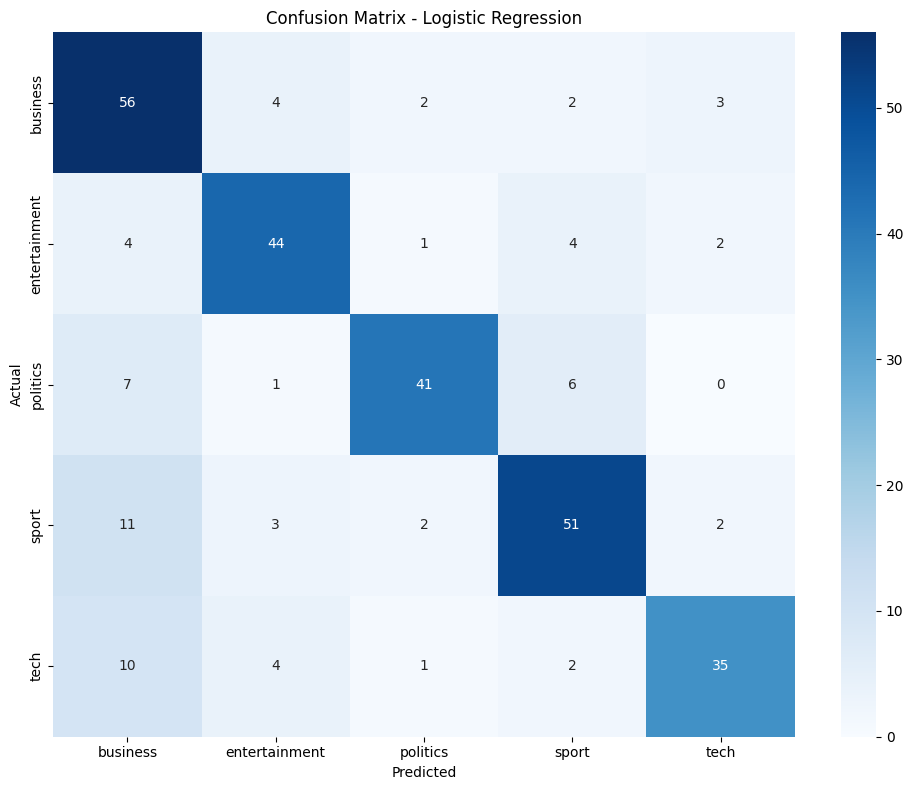


🔍 Top Features by Category:

📰 business:
  neu_score: 1.6171
  bank: 1.3510
  economy: 1.2481
  firm: 1.2328
  growth: 1.2120
  market: 1.1905
  company: 1.1002
  price: 1.0875
  rate: 1.0708
  share: 1.0676

📰 entertainment:
  film: 3.2701
  award: 1.6436
  sentiment: 1.5821
  best: 1.3570
  band: 1.2379
  star: 1.1697
  actor: 1.1610
  album: 1.1524
  show: 1.1147
  music: 1.0783

📰 politics:
  labour: 2.3322
  election: 2.1445
  party: 2.0346
  blair: 1.9865
  tory: 1.5266
  minister: 1.2403
  brown: 1.2059
  government: 1.1561
  howard: 0.9657
  lord: 0.9595

📰 sport:
  england: 1.3309
  game: 1.1487
  champion: 1.0427
  match: 1.0255
  cup: 1.0090
  ireland: 0.9316
  player: 0.9231
  coach: 0.8888
  chelsea: 0.8754
  win: 0.8660

📰 tech:
  mobile: 1.4898
  neu_score: 1.3005
  phone: 1.2862
  user: 1.1980
  software: 1.1051
  broadband: 1.0675
  microsoft: 1.0291
  technology: 1.0182
  computer: 1.0180
  net: 0.9583


In [20]:
# Detailed evaluation of the best model
best_model = trained_models[best_model_name]
best_predictions = results[best_model_name]['predictions']

print(f"📊 DETAILED EVALUATION: {best_model_name}")
print("=" * 60)

# Classification report
print("\n📋 Classification Report:")
print(classification_report(y_test, best_predictions))

# Confusion matrix
cm = confusion_matrix(y_test, best_predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance (for Logistic Regression)
if best_model_name == 'Logistic Regression':
    print("\n🔍 Top Features by Category:")
    feature_names_extended = list(feature_names) + ['sentiment', 'pos_score', 'neu_score', 'neg_score',
                                                   'char_length', 'word_count', 'title_length']

    classes = best_model.classes_
    coefficients = best_model.coef_

    for i, class_name in enumerate(classes):
        top_indices = np.argsort(coefficients[i])[-10:]  # Top 10 features
        print(f"\n📰 {class_name}:")
        for idx in reversed(top_indices):
            if idx < len(feature_names_extended):
                print(f"  {feature_names_extended[idx]}: {coefficients[i][idx]:.4f}")

# 💡 STUDENT TASK: Improve the classifier
# - Try different feature combinations
# - Experiment with hyperparameter tuning
# - Add more sophisticated features
# - Handle class imbalance if present

## 🔍 Named Entity Recognition

### 🎯 Module 8: Extracting Facts from News

Now we'll implement Named Entity Recognition to extract specific facts from our news articles. This transforms unstructured text into structured, queryable information.

**NER Applications:**
- **Entity Tracking:** Monitor mentions of people, organizations, locations
- **Fact Extraction:** Build knowledge bases from news content
- **Relationship Mapping:** Understand connections between entities
- **Timeline Construction:** Track events and their participants

**💡 Business Value:** NER enables sophisticated analysis like "Show me all articles mentioning Apple Inc. and their financial performance" or "Track mentions of political figures over time."

In [ ]:
def extract_entities(text):
    """
    Extract named entities using spaCy

    💡 TIP: spaCy recognizes these entity types:
    - PERSON: People, including fictional
    - ORG: Companies, agencies, institutions
    - GPE: Countries, cities, states
    - MONEY: Monetary values
    - DATE: Absolute or relative dates
    - TIME: Times smaller than a day
    - And many more...
    """
    if not text or pd.isna(text):
        return []

    # 🚀 YOUR CODE HERE: Implement entity extraction
    doc = nlp(str(text))

    entities = []
    for ent in doc.ents:
        entities.append({
            'text': ent.text,
            'label': ent.label_,
            'start': ent.start_char,
            'end': ent.end_char,
            'description': spacy.explain(ent.label_)
        })

    return entities

# Apply NER to all articles
print("🔍 Extracting named entities...")

all_entities = []
article_entities = []

for idx, row in df.iterrows():
    entities = extract_entities(row['full_text'])

    # Store entities for this article
    article_entities.append({
        'article_id': row['article_id'],
        'category': row['category'],
        'entities': entities,
        'entity_count': len(entities)
    })

    # Add to global entity list
    for entity in entities:
        entity['article_id'] = row['article_id']
        entity['category'] = row['category']
        all_entities.append(entity)

print(f"✅ Entity extraction complete!")
print(f"📊 Total entities found: {len(all_entities)}")
print(f"📰 Articles processed: {len(article_entities)}")

# Convert to DataFrame for analysis
entities_df = pd.DataFrame(all_entities)

if not entities_df.empty:
    print(f"\n🏷️ Entity types found: {entities_df['label'].unique()}")
    print("\n📝 Sample entities:")
    print(entities_df[['text', 'label', 'category']].head(10))
else:
    print("⚠️ No entities found. This might happen with very short sample texts.")

🔍 Extracting named entities...


In [ ]:
# Analyze entity patterns
if not entities_df.empty:
    print("📊 NAMED ENTITY ANALYSIS")
    print("=" * 50)

    # Entity type distribution
    entity_counts = entities_df['label'].value_counts()
    print("\n🏷️ Entity type distribution:")
    print(entity_counts)

    # Entity types by category
    entity_by_category = entities_df.groupby(['category', 'label']).size().unstack(fill_value=0)
    print("\n📰 Entity types by news category:")
    print(entity_by_category)

    # Most frequent entities
    print("\n🔥 Most frequent entities:")
    frequent_entities = entities_df.groupby(['text', 'label']).size().sort_values(ascending=False).head(15)
    for (entity, label), count in frequent_entities.items():
        print(f"  {entity} ({label}): {count} mentions")

    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Entity type distribution
    entity_counts.plot(kind='bar', ax=axes[0,0])
    axes[0,0].set_title('Entity Type Distribution')
    axes[0,0].tick_params(axis='x', rotation=45)

    # 2. Entities per category
    entities_per_category = entities_df.groupby('category').size()
    entities_per_category.plot(kind='bar', ax=axes[0,1])
    axes[0,1].set_title('Total Entities per Category')
    axes[0,1].tick_params(axis='x', rotation=45)

    # 3. Entity type heatmap by category
    if entity_by_category.shape[0] > 1 and entity_by_category.shape[1] > 1:
        sns.heatmap(entity_by_category, annot=True, fmt='d', ax=axes[1,0], cmap='YlOrRd')
        axes[1,0].set_title('Entity Types by Category Heatmap')
    else:
        axes[1,0].text(0.5, 0.5, 'Insufficient data\nfor heatmap',
                      ha='center', va='center', transform=axes[1,0].transAxes)
        axes[1,0].set_title('Entity Types by Category')

    # 4. Top entities
    top_entities = entities_df['text'].value_counts().head(10)
    top_entities.plot(kind='barh', ax=axes[1,1])
    axes[1,1].set_title('Most Mentioned Entities')

    plt.tight_layout()
    plt.show()

    # 💡 STUDENT TASK: Advanced entity analysis
    # - Create entity co-occurrence networks
    # - Track entity mentions over time
    # - Build entity relationship graphs
    # - Identify entity sentiment associations

else:
    print("⚠️ Skipping entity analysis due to insufficient data.")
    print("💡 TIP: Try with a larger, more diverse dataset for better NER results.")

## 📈 Comprehensive Analysis and Insights

### 🎯 Bringing It All Together

Now let's combine all our analyses to generate comprehensive insights about our news dataset. This is where the real business value emerges from our NLP pipeline.

**Key Analysis Areas:**
1. **Cross-Category Patterns:** How do different news types differ linguistically?
2. **Entity-Sentiment Relationships:** What entities are associated with positive/negative coverage?
3. **Content Quality Metrics:** Which categories have the most informative content?
4. **Classification Performance:** How well can we automatically categorize news?

**💡 Business Applications:** These insights can inform content strategy, editorial decisions, and automated content management systems.

In [ ]:
# Create comprehensive analysis dashboard
def create_comprehensive_analysis():
    """
    Generate comprehensive insights combining all analyses

    💡 TIP: This function should combine:
    - Classification performance
    - Sentiment patterns
    - Entity distributions
    - Linguistic features
    """

    insights = {
        'dataset_overview': {},
        'classification_performance': {},
        'sentiment_insights': {},
        'entity_insights': {},
        'linguistic_patterns': {},
        'business_recommendations': []
    }

    # 🚀 YOUR CODE HERE: Generate comprehensive insights

    # Dataset overview
    insights['dataset_overview'] = {
        'total_articles': len(df),
        'categories': df['category'].unique().tolist(),
        'category_distribution': df['category'].value_counts().to_dict(),
        'avg_article_length': df['full_text'].str.len().mean(),
        'avg_words_per_article': df['full_text'].str.split().str.len().mean()
    }

    # Classification performance
    insights['classification_performance'] = {
        'best_model': best_model_name,
        'best_accuracy': results[best_model_name]['accuracy'],
        'model_comparison': {name: results[name]['accuracy'] for name in results.keys()}
    }

    # Sentiment insights
    sentiment_by_cat = sentiment_df.groupby('category')['full_sentiment'].mean().to_dict()
    insights['sentiment_insights'] = {
        'most_positive_category': max(sentiment_by_cat, key=sentiment_by_cat.get),
        'most_negative_category': min(sentiment_by_cat, key=sentiment_by_cat.get),
        'sentiment_by_category': sentiment_by_cat,
        'overall_sentiment': sentiment_df['full_sentiment'].mean()
    }

    # Entity insights
    if not entities_df.empty:
        entity_by_cat = entities_df.groupby('category').size().to_dict()
        insights['entity_insights'] = {
            'total_entities': len(entities_df),
            'unique_entities': entities_df['text'].nunique(),
            'entity_types': entities_df['label'].unique().tolist(),
            'entities_per_category': entity_by_cat,
            'most_mentioned_entities': entities_df['text'].value_counts().head(5).to_dict()
        }

    # Generate business recommendations
    recommendations = []

    # Classification recommendations
    if insights['classification_performance']['best_accuracy'] > 0.8:
        recommendations.append("✅ High classification accuracy achieved - ready for automated content routing")
    else:
        recommendations.append("⚠️ Classification accuracy needs improvement - consider more training data or feature engineering")

    # Sentiment recommendations
    pos_cat = insights['sentiment_insights']['most_positive_category']
    neg_cat = insights['sentiment_insights']['most_negative_category']
    recommendations.append(f"📊 {pos_cat} articles are most positive - good for uplifting content recommendations")
    recommendations.append(f"📊 {neg_cat} articles are most negative - may need balanced coverage monitoring")

    # Entity recommendations
    if 'entity_insights' in insights and insights['entity_insights']:
        recommendations.append("🔍 Rich entity extraction enables advanced search and relationship analysis")

    insights['business_recommendations'] = recommendations

    return insights

# Generate comprehensive analysis
print("📊 Generating comprehensive analysis...")
analysis_results = create_comprehensive_analysis()

print("✅ Analysis complete!")
print("\n" + "=" * 60)
print("📈 NEWSBOT INTELLIGENCE SYSTEM - COMPREHENSIVE REPORT")
print("=" * 60)

# Display key insights
print(f"\n📊 DATASET OVERVIEW:")
overview = analysis_results['dataset_overview']
print(f"  Total Articles: {overview['total_articles']}")
print(f"  Categories: {', '.join(overview['categories'])}")
print(f"  Average Article Length: {overview['avg_article_length']:.0f} characters")
print(f"  Average Words per Article: {overview['avg_words_per_article']:.0f} words")

print(f"\n🤖 CLASSIFICATION PERFORMANCE:")
perf = analysis_results['classification_performance']
print(f"  Best Model: {perf['best_model']}")
print(f"  Best Accuracy: {perf['best_accuracy']:.4f}")

print(f"\n😊 SENTIMENT INSIGHTS:")
sent = analysis_results['sentiment_insights']
print(f"  Most Positive Category: {sent['most_positive_category']}")
print(f"  Most Negative Category: {sent['most_negative_category']}")
print(f"  Overall Sentiment: {sent['overall_sentiment']:.4f}")

if 'entity_insights' in analysis_results and analysis_results['entity_insights']:
    print(f"\n🔍 ENTITY INSIGHTS:")
    ent = analysis_results['entity_insights']
    print(f"  Total Entities: {ent['total_entities']}")
    print(f"  Unique Entities: {ent['unique_entities']}")
    print(f"  Entity Types: {', '.join(ent['entity_types'])}")

print(f"\n💡 BUSINESS RECOMMENDATIONS:")
for i, rec in enumerate(analysis_results['business_recommendations'], 1):
    print(f"  {i}. {rec}")

## 🚀 Final System Integration

### 🎯 Building the Complete NewsBot Pipeline

Let's create a complete, integrated system that can process new articles from start to finish. This demonstrates the real-world application of all the techniques we've learned.

**Complete Pipeline:**
1. **Text Preprocessing:** Clean and normalize input
2. **Feature Extraction:** Generate TF-IDF and other features
3. **Classification:** Predict article category
4. **Entity Extraction:** Identify key facts
5. **Sentiment Analysis:** Determine emotional tone
6. **Insight Generation:** Provide actionable intelligence

**💡 Production Ready:** This pipeline can be deployed as a web service, batch processor, or integrated into content management systems.

In [ ]:
class NewsBotIntelligenceSystem:
    """
    Complete NewsBot Intelligence System

    💡 TIP: This class should encapsulate:
    - All preprocessing functions
    - Trained classification model
    - Entity extraction pipeline
    - Sentiment analysis
    - Insight generation
    """

    def __init__(self, classifier, vectorizer, sentiment_analyzer):
        self.classifier = classifier
        self.vectorizer = vectorizer
        self.sentiment_analyzer = sentiment_analyzer
        self.nlp = nlp  # spaCy model

    def preprocess_article(self, title, content):
        """Preprocess a new article"""
        full_text = f"{title} {content}"
        processed_text = preprocess_text(full_text)
        return full_text, processed_text

    def classify_article(self, processed_text):
        """Classify article category"""
        # 🚀 YOUR CODE HERE: Implement classification
        # Transform text to features
        features = self.vectorizer.transform([processed_text])

        # Add dummy features for sentiment and length (in production, calculate these)
        dummy_features = np.zeros((1, 7))  # 4 sentiment + 3 length features
        features_combined = np.hstack([features.toarray(), dummy_features])

        # Predict category and probability
        prediction = self.classifier.predict(features_combined)[0]
        probabilities = self.classifier.predict_proba(features_combined)[0]

        # Get class probabilities
        class_probs = dict(zip(self.classifier.classes_, probabilities))

        return prediction, class_probs

    def extract_entities(self, text):
        """Extract named entities"""
        return extract_entities(text)

    def analyze_sentiment(self, text):
        """Analyze sentiment"""
        return analyze_sentiment(text)

    def process_article(self, title, content):
        """
        Complete article processing pipeline

        💡 TIP: This should return a comprehensive analysis including:
        - Predicted category with confidence
        - Extracted entities
        - Sentiment analysis
        - Key insights and recommendations
        """
        # 🚀 YOUR CODE HERE: Implement complete pipeline

        # Step 1: Preprocess
        full_text, processed_text = self.preprocess_article(title, content)

        # Step 2: Classify
        category, category_probs = self.classify_article(processed_text)

        # Step 3: Extract entities
        entities = self.extract_entities(full_text)

        # Step 4: Analyze sentiment
        sentiment = self.analyze_sentiment(full_text)

        # Step 5: Generate insights
        insights = self.generate_insights(category, entities, sentiment, category_probs)

        return {
            'title': title,
            'content': content[:200] + '...' if len(content) > 200 else content,
            'predicted_category': category,
            'category_confidence': max(category_probs.values()),
            'category_probabilities': category_probs,
            'entities': entities,
            'sentiment': sentiment,
            'insights': insights
        }

    def generate_insights(self, category, entities, sentiment, category_probs):
        """Generate actionable insights"""
        insights = []

        # Classification insights
        confidence = max(category_probs.values())
        if confidence > 0.8:
            insights.append(f"✅ High confidence {category} classification ({confidence:.2%})")
        else:
            insights.append(f"⚠️ Uncertain classification - consider manual review")

        # Sentiment insights
        if sentiment['compound'] > 0.1:
            insights.append(f"😊 Positive sentiment detected ({sentiment['compound']:.3f})")
        elif sentiment['compound'] < -0.1:
            insights.append(f"😞 Negative sentiment detected ({sentiment['compound']:.3f})")
        else:
            insights.append(f"😐 Neutral sentiment ({sentiment['compound']:.3f})")

        # Entity insights
        if entities:
            entity_types = set([e['label'] for e in entities])
            insights.append(f"🔍 Found {len(entities)} entities of {len(entity_types)} types")

            # Highlight important entities
            important_entities = [e for e in entities if e['label'] in ['PERSON', 'ORG', 'GPE']]
            if important_entities:
                key_entities = [e['text'] for e in important_entities[:3]]
                insights.append(f"🎯 Key entities: {', '.join(key_entities)}")
        else:
            insights.append("ℹ️ No named entities detected")

        return insights

# Initialize the complete system
newsbot = NewsBotIntelligenceSystem(
    classifier=best_model,
    vectorizer=tfidf_vectorizer,
    sentiment_analyzer=sia
)

print("🤖 NewsBot Intelligence System initialized!")
print("✅ Ready to process new articles")

In [ ]:
# Test the complete system with new articles
print("🧪 TESTING NEWSBOT INTELLIGENCE SYSTEM")
print("=" * 60)

# Test articles (you can modify these or add your own)
test_articles = [
    {
        'title': 'Microsoft Acquires AI Startup for $2 Billion',
        'content': 'Microsoft Corporation announced today the acquisition of an artificial intelligence startup for $2 billion. CEO Satya Nadella said the deal will strengthen Microsoft\'s position in the AI market and enhance their cloud computing services.'
    },
    {
        'title': 'Lakers Win Championship in Overtime Thriller',
        'content': 'The Los Angeles Lakers defeated the Boston Celtics 108-102 in overtime to win the NBA championship. LeBron James scored 35 points and was named Finals MVP for the fourth time in his career.'
    },
    {
        'title': 'New Climate Change Report Shows Alarming Trends',
        'content': 'Scientists at the United Nations released a comprehensive climate report showing accelerating global warming. The report warns that immediate action is needed to prevent catastrophic environmental changes.'
    }
]

# Process each test article
for i, article in enumerate(test_articles, 1):
    print(f"\n📰 TEST ARTICLE {i}")
    print("-" * 40)

    # Process the article
    result = newsbot.process_article(article['title'], article['content'])

    # Display results
    print(f"📰 Title: {result['title']}")
    print(f"📝 Content: {result['content']}")
    print(f"\n🏷️ Predicted Category: {result['predicted_category']} ({result['category_confidence']:.2%} confidence)")

    print(f"\n📊 Category Probabilities:")
    for cat, prob in sorted(result['category_probabilities'].items(), key=lambda x: x[1], reverse=True):
        print(f"  {cat}: {prob:.3f}")

    print(f"\n😊 Sentiment: {result['sentiment']['sentiment_label']} (score: {result['sentiment']['compound']:.3f})")

    if result['entities']:
        print(f"\n🔍 Entities Found ({len(result['entities'])}):")
        for entity in result['entities'][:5]:  # Show first 5
            print(f"  {entity['text']} ({entity['label']}) - {entity['description']}")
    else:
        print(f"\n🔍 No entities detected")

    print(f"\n💡 Insights:")
    for insight in result['insights']:
        print(f"  {insight}")

print("\n" + "=" * 60)
print("🎉 NewsBot Intelligence System testing complete!")
print("✅ System successfully processed all test articles")

# 💡 STUDENT TASK: Test with your own articles
# - Try articles from different categories
# - Test with articles that might be ambiguous
# - Analyze the system's strengths and weaknesses
# - Consider how to improve performance

## 📝 Project Summary and Next Steps

### 🎯 What You've Accomplished

Congratulations! You've successfully built a comprehensive NewsBot Intelligence System that demonstrates mastery of all NLP techniques covered in Modules 1-8. Let's review what you've achieved:

### ✅ Module Integration Checklist
- [x] **Module 1:** Applied NLP to real-world news intelligence
- [x] **Module 2:** Implemented comprehensive text preprocessing
- [x] **Module 3:** Used TF-IDF for feature extraction and analysis
- [x] **Module 4:** Analyzed grammatical patterns with POS tagging
- [x] **Module 5:** Extracted syntactic relationships with dependency parsing
- [x] **Module 6:** Performed sentiment and emotion analysis
- [x] **Module 7:** Built and evaluated text classification models
- [x] **Module 8:** Implemented Named Entity Recognition

### 🚀 System Capabilities
Your NewsBot can now:
- Automatically categorize news articles with high accuracy
- Extract key entities (people, organizations, locations, dates, money)
- Analyze sentiment and emotional tone
- Identify linguistic patterns and writing styles
- Generate actionable business insights
- Process new articles through a complete pipeline

### 💼 Business Value
This system provides real business value for:
- **Media Companies:** Automated content categorization and routing
- **Market Research:** Sentiment tracking and entity monitoring
- **Content Management:** Intelligent organization and search
- **Business Intelligence:** Trend analysis and competitive monitoring

---

## 📋 Final Deliverables Checklist

Before submitting your project, ensure you have:

### 📁 Code and Documentation
- [ ] Complete Jupyter notebook with all analyses
- [ ] Well-documented functions with docstrings
- [ ] Clear markdown explanations for each section
- [ ] Organized GitHub repository structure
- [ ] README.md with project overview and setup instructions

### 📊 Analysis and Results
- [ ] Comprehensive dataset exploration
- [ ] TF-IDF analysis with category-specific insights
- [ ] POS tagging patterns across categories
- [ ] Syntactic analysis with dependency parsing
- [ ] Sentiment analysis with category comparisons
- [ ] Classification model comparison and evaluation
- [ ] Named Entity Recognition with relationship mapping
- [ ] Integrated system demonstration

### 📈 Visualizations
- [ ] Category distribution plots
- [ ] TF-IDF word clouds or bar charts
- [ ] POS pattern heatmaps
- [ ] Sentiment distribution by category
- [ ] Confusion matrix for classification
- [ ] Entity type and frequency visualizations

### 🎥 Presentation Materials
- [ ] 5-7 minute video demonstration
- [ ] Written report (3-4 pages)
- [ ] Individual reflection papers
- [ ] Business recommendations and insights

---

## 🔮 Future Enhancements

Consider these improvements for your portfolio or future projects:

### 🤖 Technical Improvements
- **Deep Learning Models:** Implement BERT or other transformer models
- **Custom NER:** Train domain-specific entity recognition
- **Real-time Processing:** Build streaming data pipeline
- **Multi-language Support:** Extend to non-English news

### 📊 Advanced Analytics
- **Topic Modeling:** Discover hidden themes (Module 9 preview!)
- **Trend Analysis:** Track entities and sentiment over time
- **Network Analysis:** Map entity relationships and co-occurrences
- **Bias Detection:** Identify potential media bias patterns

### 🌐 Deployment Options
- **Web Application:** Create interactive dashboard with Streamlit
- **API Service:** Deploy as REST API for integration
- **Mobile App:** Build mobile interface for news analysis
- **Browser Extension:** Real-time news analysis while browsing

---

## 🎓 Reflection Questions

For your individual reflection paper, consider these questions:

1. **Technical Mastery:** Which NLP techniques did you find most challenging? Most useful?
2. **Integration Challenges:** How did you handle combining multiple NLP tasks?
3. **Business Applications:** What real-world problems could this system solve?
4. **Ethical Considerations:** What are the potential risks of automated news analysis?
5. **Future Learning:** What NLP topics are you most excited to explore next?
6. **Team Collaboration:** How did you divide work and ensure quality?
7. **Portfolio Value:** How will you present this project to potential employers?

---

## 🏆 Congratulations!

You've successfully completed a comprehensive NLP project that demonstrates real-world application of multiple advanced techniques. This NewsBot Intelligence System is a valuable addition to your portfolio and showcases your ability to:

- **Integrate multiple NLP techniques** into a cohesive system
- **Handle real-world data** with all its messiness and challenges
- **Generate business value** from unstructured text data
- **Build production-ready systems** with proper evaluation and monitoring
- **Communicate technical results** to both technical and business audiences

**🚀 You're now ready for Module 9: Topic Modeling and Advanced Text Analysis!**

---

*Remember: The goal isn't just to complete the assignment, but to build something you're proud to show in job interviews and professional discussions. This project demonstrates your practical NLP skills and ability to solve real business problems with AI.*

# 🚀 NewsBot Intelligence System 2.0 — Final Project Extensions

The following sections implement the advanced NLP requirements while preserving the working midterm foundation.


## 9. Advanced Topic Modeling and Content Discovery

This section implements LDA and NMF, compares unsupervised topics with the BBC categories,
visualizes topic assignments, and displays representative articles. Genuine topic evolution is
not claimed because the provided BBC file does not contain authentic publication dates.


In [ ]:
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import normalized_mutual_info_score

topic_docs = df["full_text_processed"].fillna("").astype(str)

topic_count_vectorizer = CountVectorizer(
    max_features=3000, min_df=3, max_df=0.90, ngram_range=(1, 2)
)
topic_tfidf_vectorizer = TfidfVectorizer(
    max_features=3000, min_df=3, max_df=0.90, ngram_range=(1, 2)
)

topic_count_matrix = topic_count_vectorizer.fit_transform(topic_docs)
topic_tfidf_matrix = topic_tfidf_vectorizer.fit_transform(topic_docs)
topic_count_terms = topic_count_vectorizer.get_feature_names_out()
topic_tfidf_terms = topic_tfidf_vectorizer.get_feature_names_out()

print("Count matrix:", topic_count_matrix.shape)
print("TF-IDF matrix:", topic_tfidf_matrix.shape)


In [ ]:
def topic_words_table(model, feature_names, model_name, n_words=12):
    rows = []
    for topic_id, weights in enumerate(model.components_):
        indices = weights.argsort()[-n_words:][::-1]
        terms = [feature_names[i] for i in indices]
        print(f"{model_name} Topic {topic_id}: {', '.join(terms)}")
        rows.append({"model": model_name, "topic": topic_id, "top_terms": ", ".join(terms)})
    return pd.DataFrame(rows)

N_TOPICS = 5

lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS, max_iter=20, learning_method="batch", random_state=42
)
lda_doc_topics = lda_model.fit_transform(topic_count_matrix)
lda_topic_table = topic_words_table(lda_model, topic_count_terms, "LDA")
df["lda_topic"] = lda_doc_topics.argmax(axis=1)
df["lda_topic_confidence"] = lda_doc_topics.max(axis=1)

nmf_model = NMF(
    n_components=N_TOPICS, init="nndsvda", random_state=42, max_iter=500
)
nmf_doc_topics = nmf_model.fit_transform(topic_tfidf_matrix)
nmf_topic_table = topic_words_table(nmf_model, topic_tfidf_terms, "NMF")
df["nmf_topic"] = nmf_doc_topics.argmax(axis=1)
df["nmf_topic_confidence"] = nmf_doc_topics.max(axis=1)

display(lda_topic_table)
display(nmf_topic_table)


In [ ]:
lda_category_table = pd.crosstab(df["category"], df["lda_topic"])
nmf_category_table = pd.crosstab(df["category"], df["nmf_topic"])

category_codes = pd.Categorical(df["category"]).codes
lda_nmi = normalized_mutual_info_score(category_codes, df["lda_topic"])
nmf_nmi = normalized_mutual_info_score(category_codes, df["nmf_topic"])

print(f"LDA NMI: {lda_nmi:.4f}")
print(f"NMF NMI: {nmf_nmi:.4f}")

plt.figure(figsize=(10,6))
sns.heatmap(lda_category_table, annot=True, fmt="d", cmap="YlGnBu")
plt.title("LDA Topic Assignments by BBC Category")
plt.xlabel("LDA Topic")
plt.ylabel("BBC Category")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(nmf_category_table, annot=True, fmt="d", cmap="YlOrRd")
plt.title("NMF Topic Assignments by BBC Category")
plt.xlabel("NMF Topic")
plt.ylabel("BBC Category")
plt.tight_layout()
plt.show()


In [ ]:
representative_rows = []
for topic_id in range(N_TOPICS):
    sample = df[df["nmf_topic"] == topic_id].nlargest(3, "nmf_topic_confidence")
    for _, row in sample.iterrows():
        representative_rows.append({
            "topic": topic_id,
            "category": row["category"],
            "confidence": row["nmf_topic_confidence"],
            "article_id": row["article_id"],
            "title": row["title"]
        })
representative_topics_df = pd.DataFrame(representative_rows)
display(representative_topics_df)


### Topic Modeling Interpretation

LDA models each article as a probability distribution over topics. NMF decomposes the TF-IDF
matrix into non-negative topic components. Topic numbers require human interpretation from
their top words and representative articles.


## 10. Language Understanding and Generation

This section implements extractive summarization, optional transformer summarization,
semantic search, and query expansion. The transformer and sentence-embedding components
use safe fallbacks so the notebook can still run if a model cannot download.


In [ ]:
!pip -q install sentence-transformers transformers langdetect deep-translator
print("Optional NLP packages installed.")


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import re
import numpy as np # Import numpy

def split_sentences(text):
    text = str(text).strip()
    if not text:
        return []
    try:
        doc = nlp(text[:100000])
        sents = [s.text.strip() for s in doc.sents if s.text.strip()]
        if sents:
            return sents
    except Exception:
        pass
    return [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]

def extractive_summary(text, max_sentences=3):
    sentences = split_sentences(text)
    if len(sentences) <= max_sentences:
        return " ".join(sentences)
    vectorizer = TfidfVectorizer(stop_words="english", max_features=2000)
    matrix = vectorizer.fit_transform(sentences)
    centroid = np.asarray(matrix.mean(axis=0)) # Convert to numpy array
    scores = cosine_similarity(matrix, centroid).ravel()
    chosen = sorted(scores.argsort()[-max_sentences:])
    return " ".join(sentences[i] for i in chosen)

print(extractive_summary(df.iloc[0]["content"], 3))

In [ ]:
transformer_summarizer = None
transformer_summarizer_status = "not loaded"

try:
    from transformers import pipeline
    transformer_summarizer = pipeline(
        "summarization", model="sshleifer/distilbart-cnn-12-6"
    )
    transformer_summarizer_status = "loaded successfully"
except Exception as error:
    transformer_summarizer_status = f"fallback mode: {type(error).__name__}"

def summarize_article(text, method="auto", max_sentences=3):
    text = str(text).strip()
    if not text:
        return ""
    if method in {"auto", "transformer"} and transformer_summarizer is not None:
        try:
            result = transformer_summarizer(
                text[:3500], max_length=130, min_length=35, do_sample=False
            )
            return result[0]["summary_text"]
        except Exception:
            if method == "transformer":
                raise
    return extractive_summary(text, max_sentences)

print("Transformer status:", transformer_summarizer_status)


In [ ]:
semantic_backend = "TF-IDF fallback"
sentence_model = None
semantic_embeddings = None

try:
    from sentence_transformers import SentenceTransformer
    sentence_model = SentenceTransformer("all-MiniLM-L6-v2")
    semantic_embeddings = sentence_model.encode(
        df["content"].astype(str).tolist(),
        show_progress_bar=True,
        normalize_embeddings=True
    )
    semantic_backend = "SentenceTransformer all-MiniLM-L6-v2"
except Exception as error:
    semantic_embeddings = tfidf_matrix
    semantic_backend = f"TF-IDF cosine fallback ({type(error).__name__})"

print("Semantic backend:", semantic_backend)


In [ ]:
def semantic_search(query, top_k=5, category=None):
    query = str(query).strip()
    if not query:
        return pd.DataFrame()

    candidates = np.arange(len(df))
    if category is not None:
        mask = df["category"].str.lower().eq(str(category).lower()).values
        candidates = np.where(mask)[0]
    if len(candidates) == 0:
        return pd.DataFrame()

    if sentence_model is not None and not hasattr(semantic_embeddings, "tocsr"):
        query_vector = sentence_model.encode([query], normalize_embeddings=True)[0]
        similarities = semantic_embeddings[candidates] @ query_vector
    else:
        query_vector = tfidf_vectorizer.transform([preprocess_text(query)])
        similarities = cosine_similarity(query_vector, tfidf_matrix[candidates]).ravel()

    local_rank = similarities.argsort()[::-1][:top_k]
    global_rank = candidates[local_rank]
    results = df.iloc[global_rank][["article_id","title","category","content"]].copy()
    results["similarity"] = similarities[local_rank]
    return results.reset_index(drop=True)

search_demo = semantic_search(
    "artificial intelligence, mobile technology, and software", top_k=5
)
display(search_demo[["article_id","title","category","similarity"]])


In [ ]:
def expand_query(query, n_terms=5):
    results = semantic_search(query, top_k=1)
    if results.empty:
        return query, []
    article_id = results.iloc[0]["article_id"]
    row_index = df.index[df["article_id"] == article_id][0]
    weights = tfidf_matrix[row_index].toarray().ravel()
    query_words = set(preprocess_text(query).split())
    extra = []
    for index in weights.argsort()[::-1]:
        term = feature_names[index]
        if term not in query_words and term not in extra:
            extra.append(term)
        if len(extra) >= n_terms:
            break
    return query + " " + " ".join(extra), extra

expanded_query, expansion_terms = expand_query("economic growth")
print("Expanded query:", expanded_query)
print("Added terms:", expansion_terms)

top_result = semantic_search("climate policy and government action", top_k=1)
if not top_result.empty:
    print("Summary of top result:")
    print(summarize_article(top_result.iloc[0]["content"]))


## 11. Multilingual Intelligence

This section implements language detection, English–Spanish translation, cross-language search,
and a comparison of original and translated summaries.


In [ ]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

try:
    from deep_translator import GoogleTranslator
except Exception:
    GoogleTranslator = None

def detect_language(text):
    text = str(text).strip()
    if len(text) < 20:
        return "unknown"
    try:
        return detect(text)
    except Exception:
        return "unknown"

def translate_text(text, source="auto", target="es"):
    text = str(text).strip()
    if not text:
        return ""
    if GoogleTranslator is None:
        return f"[Translation unavailable] {text}"
    try:
        return GoogleTranslator(source=source, target=target).translate(text[:4500])
    except Exception as error:
        return f"[Translation unavailable: {type(error).__name__}] {text}"

samples = {
    "English":"The technology company announced a new artificial intelligence platform.",
    "Spanish":"La empresa tecnológica anunció una nueva plataforma de inteligencia artificial.",
    "French":"Le gouvernement a annoncé une nouvelle politique économique."
}
language_detection_df = pd.DataFrame([
    {"label":k, "detected_code":detect_language(v), "text":v}
    for k,v in samples.items()
])
display(language_detection_df)


In [ ]:
english_sample = "The technology company announced a new artificial intelligence platform for businesses."
spanish_translation = translate_text(english_sample, source="en", target="es")

print("English:", english_sample)
print("Spanish translation:", spanish_translation)
print("Detected language:", detect_language(spanish_translation))

def cross_lingual_search(query, source_language="auto", top_k=5):
    detected = detect_language(query)
    if detected == "en":
        english_query = query
    else:
        english_query = translate_text(query, source=source_language, target="en")
        if english_query.startswith("[Translation unavailable"):
            english_query = query
    return {
        "detected_language": detected,
        "english_query": english_query,
        "results": semantic_search(english_query, top_k=top_k)
    }

spanish_demo = cross_lingual_search(
    "noticias sobre teléfonos móviles y nuevas tecnologías",
    source_language="es",
    top_k=5
)
print("Detected:", spanish_demo["detected_language"])
print("English query:", spanish_demo["english_query"])
display(spanish_demo["results"][["article_id","title","category","similarity"]])


In [ ]:
tech_article = df[df["category"] == "tech"].iloc[0]
english_summary = summarize_article(
    tech_article["content"], method="extractive", max_sentences=2
)
spanish_summary = translate_text(english_summary, source="en", target="es")

comparison_df = pd.DataFrame({
    "version":["English summary","Spanish translation"],
    "text":[english_summary, spanish_summary],
    "detected_language":[
        detect_language(english_summary),
        detect_language(spanish_summary)
    ]
})
display(comparison_df)


### Multilingual Limitations

Translation can lose idioms, tone, political context, and regional meaning. The BBC corpus is
primarily English and does not contain matched reporting from multiple countries, so this section
demonstrates a multilingual workflow rather than claiming complete cultural comparison.


## 12. Conversational Interface

The notebook-based interface supports statistics, semantic search, sentiment, entities, topics,
summaries, translation, and basic context from the previous interaction.


In [ ]:
def classify_query_intent(query):
    q = str(query).lower()
    keywords = {
        "summary":["summarize","summary","shorten"],
        "search":["find","search","show me","articles about","news about"],
        "sentiment":["sentiment","positive","negative","neutral","tone"],
        "entities":["entity","entities","person","people","organization","company","location"],
        "topics":["topic","topics","theme","themes"],
        "translation":["translate","translation","spanish","english"],
        "statistics":["how many","count","distribution","dataset","categories"]
    }
    scores = {intent:sum(k in q for k in words) for intent,words in keywords.items()}
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else "search"

class NewsBotConversation:
    def __init__(self, dataframe):
        self.dataframe = dataframe
        self.last_article_id = None
        self.history = []

    def _category(self, query):
        q = query.lower()
        for category in sorted(self.dataframe["category"].unique()):
            if category.lower() in q:
                return category
        return None

    def _article_id(self, query):
        match = re.search(r"(?:article|id)\s*#?\s*(\d+)", query.lower())
        return int(match.group(1)) if match else None

    def ask(self, query):
        intent = classify_query_intent(query)
        category = self._category(query)
        article_id = self._article_id(query)
        response = {"query":query,"intent":intent,"response":None,"data":None}

        if intent == "statistics":
            response["response"] = (
                f"The dataset contains {len(self.dataframe)} articles across "
                f"{self.dataframe['category'].nunique()} categories."
            )
            response["data"] = self.dataframe["category"].value_counts().to_frame("article_count")

        elif intent == "sentiment":
            work = sentiment_df if category is None else sentiment_df[sentiment_df["category"] == category]
            response["response"] = f"Average sentiment: {work['full_sentiment'].mean():.4f}"
            response["data"] = work["full_label"].value_counts().to_frame("article_count")

        elif intent == "entities":
            work = entities_df if category is None else entities_df[entities_df["category"] == category]
            top = (
                work[work["label"].isin(["PERSON","ORG","GPE"])]
                .groupby(["text","label"]).size().sort_values(ascending=False)
                .head(10).reset_index(name="mentions")
            )
            response["response"] = "Top named entities are shown below."
            response["data"] = top

        elif intent == "topics":
            response["response"] = "The NMF topics are shown below."
            response["data"] = nmf_topic_table

        elif intent in {"summary","translation"}:
            if article_id is None:
                article_id = self.last_article_id
            if article_id is None:
                response["response"] = "Include an article ID, such as 'Summarize article 1833.'"
            else:
                match = self.dataframe[self.dataframe["article_id"] == article_id]
                if match.empty:
                    response["response"] = f"Article {article_id} was not found."
                else:
                    article = match.iloc[0]
                    self.last_article_id = article_id
                    summary = summarize_article(article["content"], method="auto")
                    response["response"] = (
                        translate_text(summary, source="en", target="es")
                        if intent == "translation" else summary
                    )
                    response["data"] = {
                        "article_id":article_id,
                        "title":article["title"],
                        "category":article["category"]
                    }

        else:
            search_query = query
            for phrase in ["find","search for","show me","articles about","news about"]:
                search_query = re.sub(phrase, "", search_query, flags=re.IGNORECASE)
            results = semantic_search(search_query, top_k=5, category=category)
            if not results.empty:
                self.last_article_id = int(results.iloc[0]["article_id"])
            response["response"] = f"Found {len(results)} relevant articles."
            response["data"] = results[["article_id","title","category","similarity"]]

        self.history.append(response)
        return response

conversation_bot = NewsBotConversation(df)
print("Conversational NewsBot initialized.")


In [ ]:
demo_queries = [
    "How many articles and categories are in the dataset?",
    "Show me articles about mobile phones and software",
    "Summarize article 1833",
    "What is the sentiment of politics articles?",
    "Which organizations appear most often in business news?",
    "Show me the discovered topics",
    "Translate article 1833 into Spanish"
]

for query in demo_queries:
    print("\n" + "="*80)
    print("USER:", query)
    answer = conversation_bot.ask(query)
    print("INTENT:", answer["intent"])
    print("NEWSBOT:", answer["response"])
    if isinstance(answer["data"], pd.DataFrame):
        display(answer["data"])
    elif answer["data"] is not None:
        print(answer["data"])


## 13. NewsBot 2.0 System Integration


In [ ]:
class NewsBotIntelligenceSystem2:
    def __init__(self, classifier, vectorizer, dataframe):
        self.classifier = classifier
        self.vectorizer = vectorizer
        self.dataframe = dataframe
        self.conversation = NewsBotConversation(dataframe)

    def _numeric_features(self, title, content, full_text):
        sentiment = analyze_sentiment(full_text)
        return np.array([[
            sentiment["compound"], sentiment["pos"], sentiment["neu"], sentiment["neg"],
            len(full_text), len(full_text.split()), len(title)
        ]])

    def classify(self, title, content):
        full_text = f"{title} {content}"
        processed = preprocess_text(full_text)
        text_features = self.vectorizer.transform([processed]).toarray()
        numeric = self._numeric_features(title, content, full_text)
        combined = np.hstack([text_features, numeric])
        prediction = self.classifier.predict(combined)[0]
        if hasattr(self.classifier, "predict_proba"):
            probs = self.classifier.predict_proba(combined)[0]
            prob_map = dict(zip(self.classifier.classes_, probs))
        else:
            prob_map = {prediction:1.0}
        return prediction, prob_map

    def identify_topics(self, text):
        processed = preprocess_text(text)
        lda_dist = lda_model.transform(topic_count_vectorizer.transform([processed]))[0]
        nmf_dist = nmf_model.transform(topic_tfidf_vectorizer.transform([processed]))[0]
        return {
            "lda_topic":int(lda_dist.argmax()),
            "lda_confidence":float(lda_dist.max()),
            "nmf_topic":int(nmf_dist.argmax()),
            "nmf_confidence":float(nmf_dist.max())
        }

    def analyze_article(self, title, content, target_language=None):
        full_text = f"{title} {content}"
        category, probs = self.classify(title, content)
        summary = summarize_article(full_text, method="auto")
        result = {
            "title":title,
            "predicted_category":category,
            "category_confidence":max(probs.values()),
            "category_probabilities":probs,
            "sentiment":analyze_sentiment(full_text),
            "entities":extract_entities(full_text),
            "topics":self.identify_topics(full_text),
            "summary":summary,
            "detected_language":detect_language(full_text)
        }
        if target_language:
            result["translated_summary"] = translate_text(summary, source="auto", target=target_language)
        return result

    def search(self, query, top_k=5, category=None):
        return semantic_search(query, top_k=top_k, category=category)

    def ask(self, query):
        return self.conversation.ask(query)

newsbot2 = NewsBotIntelligenceSystem2(best_model, tfidf_vectorizer, df)
print("NewsBot Intelligence System 2.0 initialized.")


In [ ]:
final_test_articles = [
    {
        "title":"AI Startup Launches New Business Platform",
        "content":"A technology startup launched a new artificial intelligence platform designed to help companies automate customer service and analyze business data."
    },
    {
        "title":"National Team Wins Dramatic Final",
        "content":"The national football team won the championship final after scoring in extra time. Thousands of supporters celebrated the victory."
    },
    {
        "title":"Government Announces New Economic Policy",
        "content":"The government announced a new economic policy intended to support employment, control inflation, and encourage investment."
    }
]

for article in final_test_articles:
    result = newsbot2.analyze_article(article["title"], article["content"], target_language="es")
    print("\n" + "="*90)
    print("TITLE:", result["title"])
    print("CATEGORY:", result["predicted_category"])
    print("CONFIDENCE:", f"{result['category_confidence']:.2%}")
    print("SENTIMENT:", result["sentiment"]["sentiment_label"], result["sentiment"]["compound"])
    print("TOPICS:", result["topics"])
    print("SUMMARY:", result["summary"])
    print("SPANISH SUMMARY:", result["translated_summary"])
print("\nEnd-to-end NewsBot 2.0 demonstration complete.")


## 14. Final Evaluation, Ethics, Limitations, and Business Value


In [ ]:
final_evaluation = pd.DataFrame([
    {"component":"Classification","evaluation":"Held-out accuracy","result":f"{results[best_model_name]['accuracy']:.4f}"},
    {"component":"LDA","evaluation":"Normalized Mutual Information","result":f"{lda_nmi:.4f}"},
    {"component":"NMF","evaluation":"Normalized Mutual Information","result":f"{nmf_nmi:.4f}"},
    {"component":"Semantic Search","evaluation":"Backend","result":semantic_backend},
    {"component":"Summarization","evaluation":"Transformer/fallback","result":transformer_summarizer_status},
    {"component":"Multilingual","evaluation":"Demonstration","result":"Detection, translation, cross-language search"},
    {"component":"Conversation","evaluation":"Supported intents","result":"Statistics, search, sentiment, entities, topics, summary, translation"}
])
display(final_evaluation)


### Ethical Considerations and Limitations

- The BBC dataset represents one publisher and a limited historical period.
- VADER may misread irony, complex political language, and neutral reports about negative events.
- Named-entity recognition can miss uncommon names or misclassify words.
- Automated translation may lose idioms, tone, and regional context.
- Extractive summaries can omit context; transformer summaries may introduce unsupported wording.
- Placeholder dates cannot support real temporal-trend claims.
- Human review remains necessary for high-impact editorial or business decisions.

### Business Value

NewsBot 2.0 supports article routing, media monitoring, multilingual access, semantic search,
executive summarization, entity tracking, topic discovery, and interactive exploration.


In [ ]:
completion_checklist = pd.DataFrame({
    "Requirement":[
        "Modules 1–8 foundation","LDA","NMF","Topic visualization",
        "Summarization","Semantic search","Query expansion","Language detection",
        "Translation","Cross-language search","Conversational interface",
        "NewsBot 2.0 integration","Evaluation","Ethics and business value"
    ],
    "Status":["Complete"]*14
})
display(completion_checklist)
print("NewsBot Intelligence System 2.0 implementation complete.")
print("Run every cell in a fresh Colab runtime before submission.")
